# Rede Neural para Detecção de Alzheimer

## Objetivo
Este notebook implementa uma **Rede Neural Artificial (MLP - Multi-Layer Perceptron)** otimizada para classificação binária, com o objetivo de determinar se um paciente tem Alzheimer ou não.

## Métricas Importantes para Diagnóstico Médico
Para problemas de diagnóstico médico, algumas métricas são mais relevantes:
- **Recall (Sensibilidade)**: Capacidade de identificar corretamente os casos positivos (doentes)
- **Precisão**: Proporção de diagnósticos positivos que são realmente corretos
- **F1-Score**: Média harmônica entre precisão e recall
- **AUC-ROC**: Área sob a curva ROC, mede a capacidade discriminativa do modelo

**Nota**: Em diagnósticos médicos, geralmente preferimos minimizar falsos negativos (recall alto), pois é mais grave não detectar uma doença do que um falso alarme.

## 1. Importação das Bibliotecas

Importamos todas as bibliotecas necessárias para:
- Manipulação de dados (pandas, numpy)
- Visualização (matplotlib, seaborn)
- Machine Learning (sklearn, imblearn)

In [ ]:
# ==============================================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================

# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')  # Estilo limpo e profissional
plt.rcParams['figure.figsize'] = (12, 8)  # Tamanho padrão dos gráficos
plt.rcParams['font.size'] = 12  # Tamanho da fonte
plt.rcParams['axes.titlesize'] = 14  # Tamanho do título
plt.rcParams['axes.labelsize'] = 12  # Tamanho dos labels

# Bibliotecas para Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler  # IMPORTANTE: Normalização dos dados
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score
)

# Biblioteca para balanceamento de dados
from imblearn.over_sampling import SMOTE  # Melhor que NearMiss para dados médicos
from imblearn.under_sampling import NearMiss

# Suprimir warnings desnecessários
import warnings
warnings.filterwarnings('ignore')

# Seed para reproducibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento e Exploração Inicial dos Dados

In [ ]:
# ==============================================================================
# CARREGAMENTO DOS DADOS
# ==============================================================================

# Detecta se está rodando no Google Colab ou localmente
import os

try:
    # Tenta importar google.colab (só funciona no Colab)
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    csv_path = '/content/drive/MyDrive/alzheimers_disease_data.csv'
    print('Rodando no Google Colab')
except ImportError:
    # Se não estiver no Colab, abre diálogo para selecionar arquivo
    print('Rodando localmente - Selecione o arquivo CSV')
    import tkinter as tk
    from tkinter import filedialog
    
    root = tk.Tk()
    root.withdraw()  # Esconde a janela principal
    root.attributes('-topmost', True)  # Traz o diálogo para frente
    
    csv_path = filedialog.askopenfilename(
        title='Selecione o arquivo alzheimers_disease_data.csv',
        filetypes=[('CSV files', '*.csv'), ('All files', '*.*')]
    )
    root.destroy()
    
    if not csv_path:
        raise FileNotFoundError('Nenhum arquivo selecionado!')

# Carregamento do dataset
df = pd.read_csv(csv_path)

print(f'Dataset carregado com sucesso!')
print(f'Arquivo: {csv_path}')
print(f'Dimensões: {df.shape[0]} amostras x {df.shape[1]} features')

Rodando localmente - Selecione o arquivo CSV
Dataset carregado com sucesso!
Arquivo: C:/Users/pokab/Downloads/Codigos/Python/Redes Neurais/alzheimers_disease_data.csv
Dimensões: 2149 amostras x 35 features


In [ ]:
# ==============================================================================
# EXPLORAÇÃO INICIAL DOS DADOS
# ==============================================================================

# Visualização das primeiras linhas
print("=" * 60)
print("PRIMEIRAS LINHAS DO DATASET")
print("=" * 60)
display(df.head())

# Informações gerais sobre o dataset
print("\n" + "=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
print(df.info())

# Estatísticas descritivas
print("\n" + "=" * 60)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 60)
display(df.describe())

PRIMEIRAS LINHAS DO DATASET


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid



INFORMAÇÕES DO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 3. Pré-processamento dos Dados

In [ ]:
# ==============================================================================
# PRÉ-PROCESSAMENTO DOS DADOS
# ==============================================================================

# Remoção de colunas irrelevantes para o modelo
# PatientID: Identificador único, não tem valor preditivo
# DoctorInCharge: Nome do médico, informação confidencial e não relevante
colunas_remover = ['PatientID', 'DoctorInCharge']
df = df.drop(columns=colunas_remover)
print(f"Colunas removidas: {colunas_remover}")
print(f"Novas dimensões: {df.shape}")

# Verificação de valores nulos
print("\n" + "=" * 60)
print("VERIFICAÇÃO DE VALORES NULOS")
print("=" * 60)
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print("Não há valores nulos no dataset!")
else:
    print("Valores nulos por coluna:")
    print(nulos[nulos > 0])

# Verificação de duplicatas
print("\n" + "=" * 60)
print("VERIFICAÇÃO DE DUPLICATAS")
print("=" * 60)
duplicatas = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicatas}")

if duplicatas > 0:
    df = df.drop_duplicates()
    print(f"Duplicatas removidas. Novas dimensões: {df.shape}")

Colunas removidas: ['PatientID', 'DoctorInCharge']
Novas dimensões: (2149, 33)

VERIFICAÇÃO DE VALORES NULOS
Não há valores nulos no dataset!

VERIFICAÇÃO DE DUPLICATAS
Número de linhas duplicadas: 0


## 4. Análise Exploratória de Dados (EDA)

Distribuição da variável alvo:
  - Saudável (0): 1389 (64.6%)
  - Com Alzheimer (1): 760 (35.4%)
  - Razão de desbalanceamento: 1.83:1


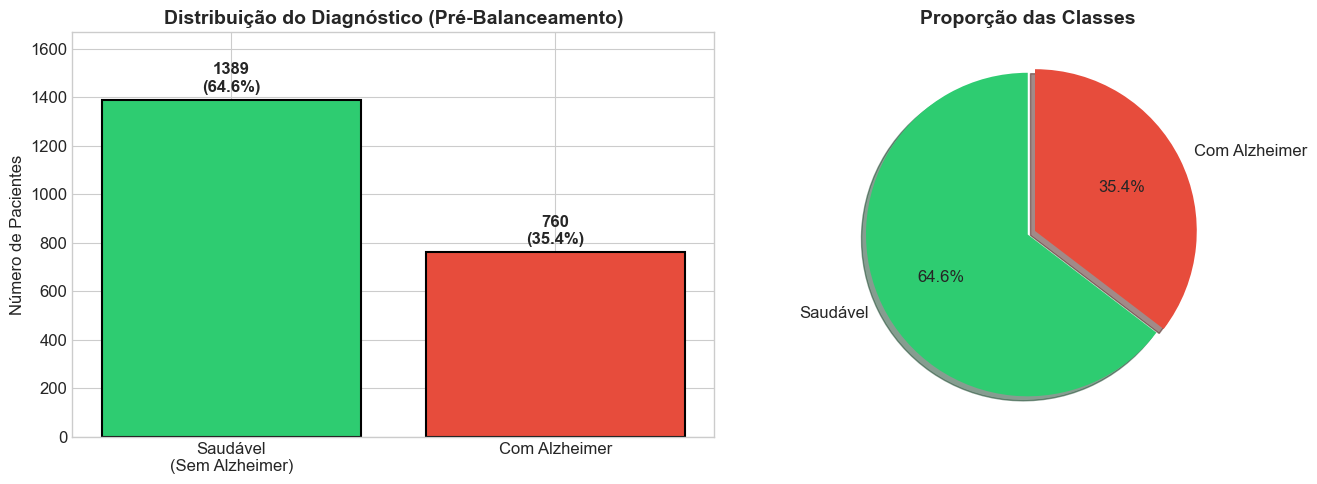

In [ ]:
# ==============================================================================
# ANÁLISE DA VARIÁVEL ALVO (Diagnosis)
# ==============================================================================

# Contagem das classes
contagem_classes = df['Diagnosis'].value_counts()
print("Distribuição da variável alvo:")
print(f"  - Saudável (0): {contagem_classes[0]} ({contagem_classes[0]/len(df)*100:.1f}%)")
print(f"  - Com Alzheimer (1): {contagem_classes[1]} ({contagem_classes[1]/len(df)*100:.1f}%)")
print(f"  - Razão de desbalanceamento: {contagem_classes[0]/contagem_classes[1]:.2f}:1")

# Gráfico de distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
colors = ['#2ecc71', '#e74c3c']  # Verde para saudável, vermelho para doente
bars = axes[0].bar(['Saudável\n(Sem Alzheimer)', 'Com Alzheimer'], 
                   [contagem_classes[0], contagem_classes[1]], 
                   color=colors, edgecolor='black', linewidth=1.5)

# Adicionar valores nas barras
for bar, count in zip(bars, [contagem_classes[0], contagem_classes[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
                 f'{count}\n({count/len(df)*100:.1f}%)', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_title('Distribuição do Diagnóstico (Pré-Balanceamento)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de Pacientes', fontsize=12)
axes[0].set_ylim(0, max(contagem_classes) * 1.2)

# Gráfico de pizza
axes[1].pie([contagem_classes[0], contagem_classes[1]], 
            labels=['Saudável', 'Com Alzheimer'],
            autopct='%1.1f%%', 
            colors=colors,
            explode=(0, 0.05),
            shadow=True,
            startangle=90)
axes[1].set_title('Proporção das Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()

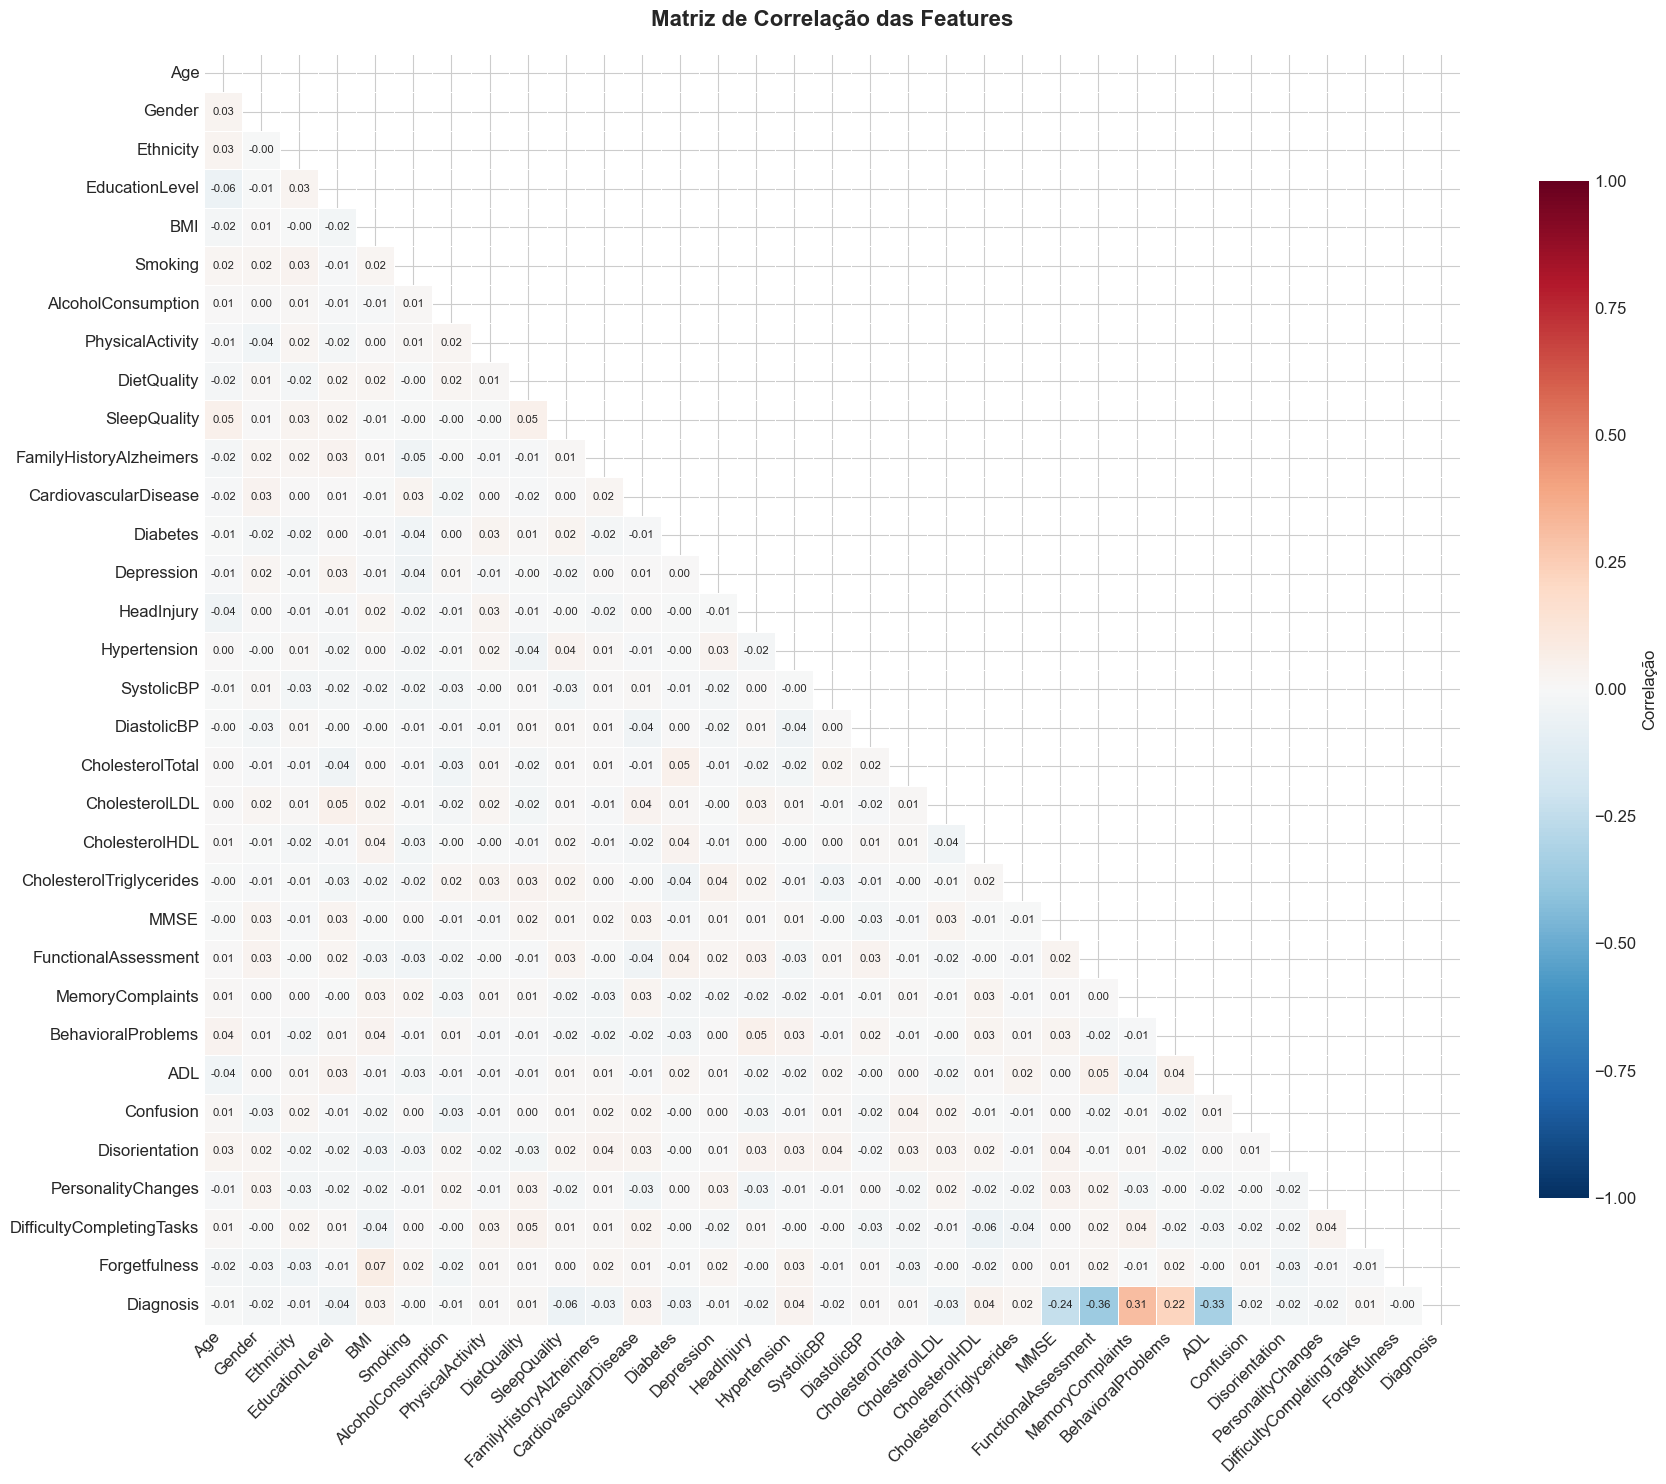


TOP 10 CORRELAÇÕES COM A VARIÁVEL ALVO (Diagnosis)
 1. FunctionalAssessment          : -0.3649
 2. ADL                           : -0.3323
 3. MemoryComplaints              : +0.3067
 4. MMSE                          : -0.2371
 5. BehavioralProblems            : +0.2244
 6. SleepQuality                  : -0.0565
 7. EducationLevel                : -0.0440
 8. CholesterolHDL                : +0.0426
 9. Hypertension                  : +0.0351
10. FamilyHistoryAlzheimers       : -0.0329


In [ ]:
# ==============================================================================
# MATRIZ DE CORRELAÇÃO OTIMIZADA
# ==============================================================================

# Calculando a matriz de correlação
correlation_matrix = df.corr()

# Criando máscara para mostrar apenas metade da matriz (evita redundância)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Figura com tamanho adequado
fig, ax = plt.subplots(figsize=(18, 15))

# Heatmap com cores divergentes centradas em zero
heatmap = sns.heatmap(
    correlation_matrix, 
    mask=mask,
    annot=True, 
    fmt='.2f',  # Duas casas decimais
    cmap='RdBu_r',  # Paleta de cores: vermelho (negativo) -> branco (zero) -> azul (positivo)
    vmin=-1, vmax=1,  # Limites fixos para correlação
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Correlação', 'shrink': 0.8}
)

plt.title('Matriz de Correlação das Features', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlações mais fortes com a variável alvo
print("\n" + "=" * 60)
print("TOP 10 CORRELAÇÕES COM A VARIÁVEL ALVO (Diagnosis)")
print("=" * 60)
correlacoes_alvo = correlation_matrix['Diagnosis'].drop('Diagnosis').abs().sort_values(ascending=False)
for i, (feature, corr) in enumerate(correlacoes_alvo.head(10).items(), 1):
    sinal = '+' if correlation_matrix.loc[feature, 'Diagnosis'] > 0 else '-'
    print(f"{i:2d}. {feature:30s}: {sinal}{corr:.4f}")

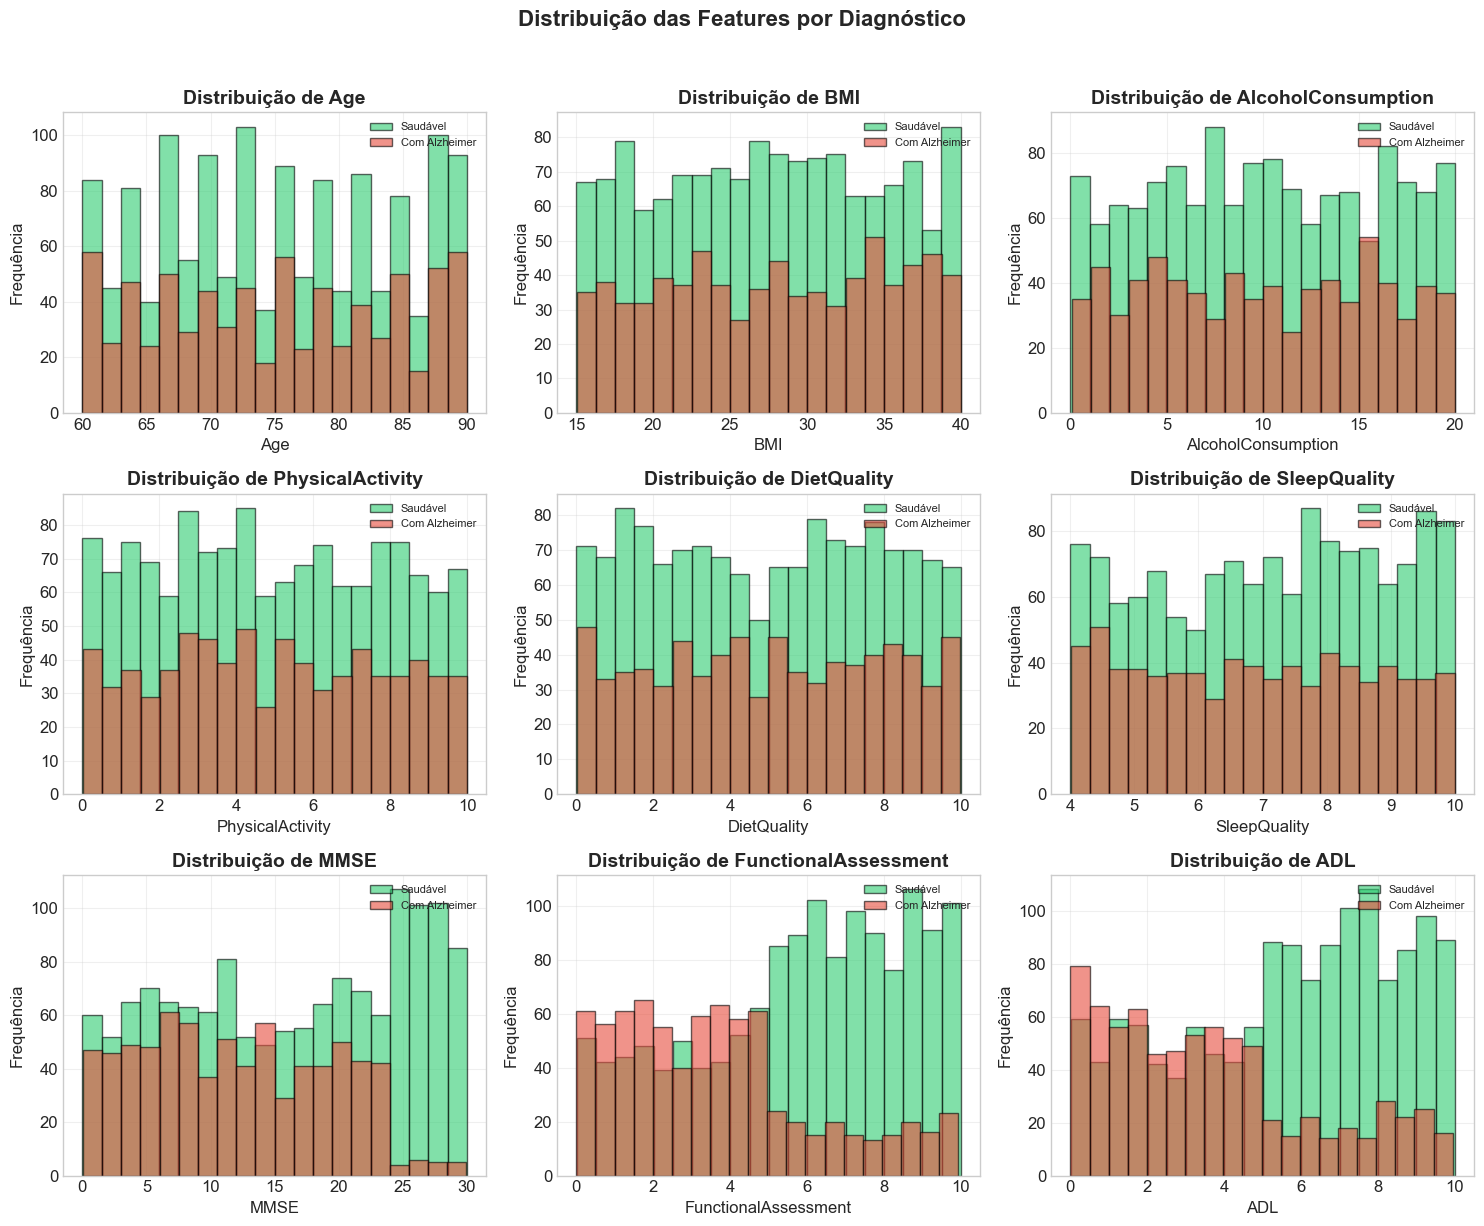

In [ ]:
# ==============================================================================
# DISTRIBUIÇÃO DAS FEATURES NUMÉRICAS
# ==============================================================================

# Selecionando features numéricas contínuas para visualização
features_continuas = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 
                      'DietQuality', 'SleepQuality', 'MMSE', 'FunctionalAssessment', 'ADL']

# Verificando quais existem no dataset
features_continuas = [f for f in features_continuas if f in df.columns]

# Criando subplots
n_cols = 3
n_rows = (len(features_continuas) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for idx, feature in enumerate(features_continuas):
    ax = axes[idx]
    
    # Histograma com separação por classe
    for diagnosis, color, label in [(0, '#2ecc71', 'Saudável'), (1, '#e74c3c', 'Com Alzheimer')]:
        data = df[df['Diagnosis'] == diagnosis][feature]
        ax.hist(data, bins=20, alpha=0.6, color=color, label=label, edgecolor='black')
    
    ax.set_title(f'Distribuição de {feature}', fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequência')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Remover subplots vazios
for idx in range(len(features_continuas), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuição das Features por Diagnóstico', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribuicao_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Balanceamento dos Dados

O dataset está desbalanceado. Utilizaremos **SMOTE** (Synthetic Minority Over-sampling Technique) que é mais adequado para dados médicos pois:
- Cria amostras sintéticas da classe minoritária
- Preserva mais informação que undersampling
- Reduz o risco de perder casos importantes de Alzheimer

In [ ]:
# ==============================================================================
# SEPARAÇÃO DE FEATURES E TARGET
# ==============================================================================

# Separando features (X) e variável alvo (y)
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nNomes das features ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

Features (X): (2149, 32)
Target (y): (2149,)

Nomes das features (32):
   1. Age
   2. Gender
   3. Ethnicity
   4. EducationLevel
   5. BMI
   6. Smoking
   7. AlcoholConsumption
   8. PhysicalActivity
   9. DietQuality
  10. SleepQuality
  11. FamilyHistoryAlzheimers
  12. CardiovascularDisease
  13. Diabetes
  14. Depression
  15. HeadInjury
  16. Hypertension
  17. SystolicBP
  18. DiastolicBP
  19. CholesterolTotal
  20. CholesterolLDL
  21. CholesterolHDL
  22. CholesterolTriglycerides
  23. MMSE
  24. FunctionalAssessment
  25. MemoryComplaints
  26. BehavioralProblems
  27. ADL
  28. Confusion
  29. Disorientation
  30. PersonalityChanges
  31. DifficultyCompletingTasks
  32. Forgetfulness


BALANCEAMENTO DOS DADOS COM SMOTE

Antes do balanceamento:
  - Classe 0 (Saudável): 1389
  - Classe 1 (Alzheimer): 760
  - Total: 2149

Após o balanceamento (SMOTE):
  - Classe 0 (Saudável): 1389
  - Classe 1 (Alzheimer): 1389
  - Total: 2778


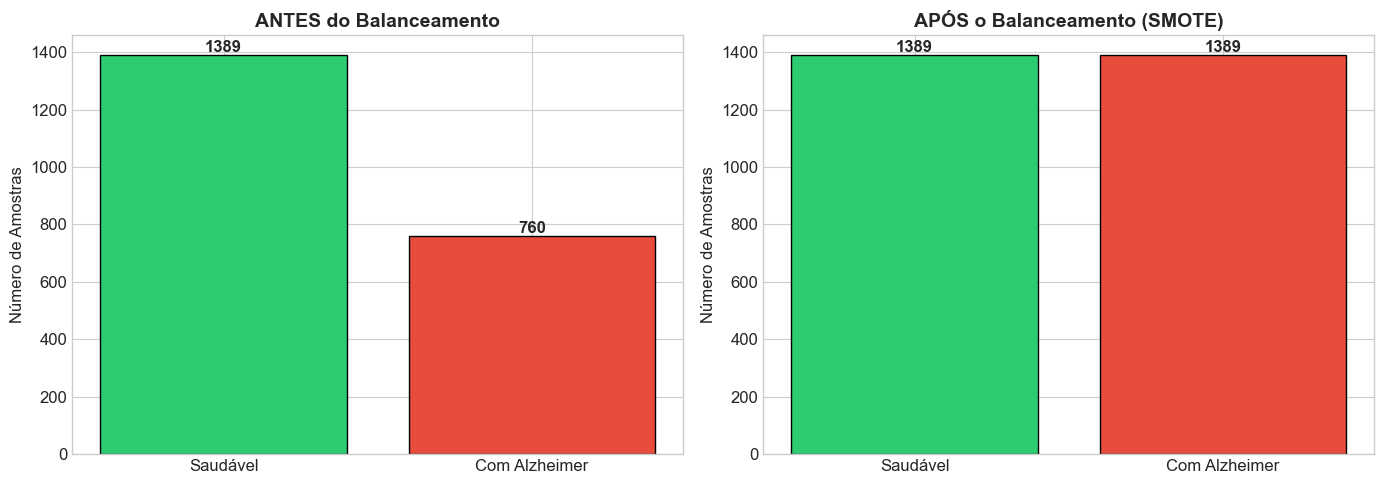

In [ ]:
# ==============================================================================
# BALANCEAMENTO COM SMOTE
# ==============================================================================

# Aplicando SMOTE para balancear as classes
# SMOTE cria novas amostras sintéticas da classe minoritária usando k-vizinhos
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("=" * 60)
print("BALANCEAMENTO DOS DADOS COM SMOTE")
print("=" * 60)
print(f"\nAntes do balanceamento:")
print(f"  - Classe 0 (Saudável): {sum(y == 0)}")
print(f"  - Classe 1 (Alzheimer): {sum(y == 1)}")
print(f"  - Total: {len(y)}")

print(f"\nApós o balanceamento (SMOTE):")
print(f"  - Classe 0 (Saudável): {sum(y_balanced == 0)}")
print(f"  - Classe 1 (Alzheimer): {sum(y_balanced == 1)}")
print(f"  - Total: {len(y_balanced)}")

# Visualização do balanceamento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
colors = ['#2ecc71', '#e74c3c']
bars1 = axes[0].bar(['Saudável', 'Com Alzheimer'], [sum(y == 0), sum(y == 1)], color=colors, edgecolor='black')
axes[0].set_title('ANTES do Balanceamento', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de Amostras')
for bar, count in zip(bars1, [sum(y == 0), sum(y == 1)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(count), ha='center', fontweight='bold')

# Depois
bars2 = axes[1].bar(['Saudável', 'Com Alzheimer'], [sum(y_balanced == 0), sum(y_balanced == 1)], color=colors, edgecolor='black')
axes[1].set_title('APÓS o Balanceamento (SMOTE)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Número de Amostras')
for bar, count in zip(bars2, [sum(y_balanced == 0), sum(y_balanced == 1)]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('balanceamento_smote.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.1 Comparação: SMOTE (Oversampling) vs NearMiss (Undersampling)

Existem duas abordagens principais para lidar com dados desbalanceados:

### **SMOTE (Synthetic Minority Over-sampling Technique) - Oversampling**
- **Cria** novas amostras sintéticas da classe minoritária
- Utiliza interpolação entre vizinhos próximos (k-NN)
- **Vantagens**: Preserva todas as amostras originais, aumenta a quantidade de dados
- **Desvantagens**: Pode criar ruído, amostras sintéticas podem não ser realistas

### **NearMiss - Undersampling**
- **Remove** amostras da classe majoritária
- Seleciona amostras mais próximas da fronteira de decisão
- **Vantagens**: Treino mais rápido, sem dados sintéticos
- **Desvantagens**: Perde informação, pode remover casos importantes

Vamos comparar as duas técnicas treinando modelos idênticos e avaliando o desempenho.

In [ ]:
# ==============================================================================
# COMPARAÇÃO: SMOTE (OVERSAMPLING) vs NEARMISS (UNDERSAMPLING)
# ==============================================================================

from imblearn.under_sampling import NearMiss

print("=" * 70)
print("COMPARAÇÃO: SMOTE (Oversampling) vs NearMiss (Undersampling)")
print("=" * 70)

# 1. Aplicar SMOTE (Oversampling) - já temos X_balanced e y_balanced
print("\n" + "-" * 50)
print("1. SMOTE (Oversampling)")
print("-" * 50)
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X, y)
print(f"   Dados originais: {len(y)} amostras")
print(f"   Após SMOTE: {len(y_smote)} amostras")
print(f"   Classe 0 (Saudável): {sum(y_smote == 0)}")
print(f"   Classe 1 (Alzheimer): {sum(y_smote == 1)}")

# 2. Aplicar NearMiss (Undersampling)
print("\n" + "-" * 50)
print("2. NearMiss (Undersampling)")
print("-" * 50)
nearmiss = NearMiss(version=1)  # version=1: seleciona amostras mais próximas
X_nearmiss, y_nearmiss = nearmiss.fit_resample(X, y)
print(f"   Dados originais: {len(y)} amostras")
print(f"   Após NearMiss: {len(y_nearmiss)} amostras")
print(f"   Classe 0 (Saudável): {sum(y_nearmiss == 0)}")
print(f"   Classe 1 (Alzheimer): {sum(y_nearmiss == 1)}")

# 3. Preparar dados para treino
# SMOTE
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X_smote, y_smote, test_size=0.25, random_state=RANDOM_STATE, stratify=y_smote
)
scaler_smote = StandardScaler()
X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
X_test_smote_scaled = scaler_smote.transform(X_test_smote)

# NearMiss
X_train_nearmiss, X_test_nearmiss, y_train_nearmiss, y_test_nearmiss = train_test_split(
    X_nearmiss, y_nearmiss, test_size=0.25, random_state=RANDOM_STATE, stratify=y_nearmiss
)
scaler_nearmiss = StandardScaler()
X_train_nearmiss_scaled = scaler_nearmiss.fit_transform(X_train_nearmiss)
X_test_nearmiss_scaled = scaler_nearmiss.transform(X_test_nearmiss)

print("\n" + "-" * 50)
print("3. Conjuntos de Treino/Teste preparados")
print("-" * 50)
print(f"   SMOTE - Treino: {len(y_train_smote)}, Teste: {len(y_test_smote)}")
print(f"   NearMiss - Treino: {len(y_train_nearmiss)}, Teste: {len(y_test_nearmiss)}")

COMPARAÇÃO: SMOTE (Oversampling) vs NearMiss (Undersampling)

--------------------------------------------------
1. SMOTE (Oversampling)
--------------------------------------------------
   Dados originais: 2149 amostras
   Após SMOTE: 2778 amostras
   Classe 0 (Saudável): 1389
   Classe 1 (Alzheimer): 1389

--------------------------------------------------
2. NearMiss (Undersampling)
--------------------------------------------------
   Dados originais: 2149 amostras
   Após NearMiss: 1520 amostras
   Classe 0 (Saudável): 760
   Classe 1 (Alzheimer): 760

--------------------------------------------------
3. Conjuntos de Treino/Teste preparados
--------------------------------------------------
   SMOTE - Treino: 2083, Teste: 695
   NearMiss - Treino: 1140, Teste: 380


In [ ]:
# ==============================================================================
# TREINAR MODELOS COM CADA TÉCNICA DE BALANCEAMENTO
# ==============================================================================

# Configuração do modelo (mesma para ambos para comparação justa)
mlp_config_compare = {
    'hidden_layer_sizes': (128, 64),
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0001,
    'learning_rate_init': 0.001,
    'max_iter': 500,
    'random_state': RANDOM_STATE,
    'early_stopping': True,
    'validation_fraction': 0.15
}

print("\n" + "-" * 50)
print("4. Treinando modelos...")
print("-" * 50)

# Modelo com SMOTE
print("   Treinando modelo com SMOTE...")
mlp_smote = MLPClassifier(**mlp_config_compare)
mlp_smote.fit(X_train_smote_scaled, y_train_smote)
y_pred_smote = mlp_smote.predict(X_test_smote_scaled)
y_proba_smote = mlp_smote.predict_proba(X_test_smote_scaled)[:, 1]
print(f"   SMOTE - Épocas: {mlp_smote.n_iter_}")

# Modelo com NearMiss
print("   Treinando modelo com NearMiss...")
mlp_nearmiss = MLPClassifier(**mlp_config_compare)
mlp_nearmiss.fit(X_train_nearmiss_scaled, y_train_nearmiss)
y_pred_nearmiss = mlp_nearmiss.predict(X_test_nearmiss_scaled)
y_proba_nearmiss = mlp_nearmiss.predict_proba(X_test_nearmiss_scaled)[:, 1]
print(f"   NearMiss - Épocas: {mlp_nearmiss.n_iter_}")

print("\n   Modelos treinados com sucesso!")


--------------------------------------------------
4. Treinando modelos...
--------------------------------------------------
   Treinando modelo com SMOTE...
   SMOTE - Épocas: 21
   Treinando modelo com NearMiss...
   NearMiss - Épocas: 25

   Modelos treinados com sucesso!


In [ ]:
# ==============================================================================
# CALCULAR E COMPARAR MÉTRICAS
# ==============================================================================

# Métricas SMOTE
acc_smote = accuracy_score(y_test_smote, y_pred_smote)
prec_smote = precision_score(y_test_smote, y_pred_smote)
rec_smote = recall_score(y_test_smote, y_pred_smote)
f1_smote = f1_score(y_test_smote, y_pred_smote)
fpr_smote, tpr_smote, _ = roc_curve(y_test_smote, y_proba_smote)
auc_smote = auc(fpr_smote, tpr_smote)
cm_smote = confusion_matrix(y_test_smote, y_pred_smote)

# Métricas NearMiss
acc_nearmiss = accuracy_score(y_test_nearmiss, y_pred_nearmiss)
prec_nearmiss = precision_score(y_test_nearmiss, y_pred_nearmiss)
rec_nearmiss = recall_score(y_test_nearmiss, y_pred_nearmiss)
f1_nearmiss = f1_score(y_test_nearmiss, y_pred_nearmiss)
fpr_nearmiss, tpr_nearmiss, _ = roc_curve(y_test_nearmiss, y_proba_nearmiss)
auc_nearmiss = auc(fpr_nearmiss, tpr_nearmiss)
cm_nearmiss = confusion_matrix(y_test_nearmiss, y_pred_nearmiss)

# Tabela comparativa
print("\n" + "=" * 70)
print("TABELA COMPARATIVA: SMOTE vs NearMiss")
print("=" * 70)
print(f"\n{'Métrica':<20} {'SMOTE':<15} {'NearMiss':<15} {'Diferença':<15} {'Melhor':<10}")
print("-" * 75)

# Acurácia
diff_acc = acc_smote - acc_nearmiss
melhor_acc = 'SMOTE' if diff_acc > 0 else 'NearMiss' if diff_acc < 0 else 'Empate'
print(f"{'Acurácia':<20} {acc_smote*100:>12.2f}% {acc_nearmiss*100:>12.2f}% {diff_acc*100:>+12.2f}% {melhor_acc:<10}")

# Precisão
diff_prec = prec_smote - prec_nearmiss
melhor_prec = 'SMOTE' if diff_prec > 0 else 'NearMiss' if diff_prec < 0 else 'Empate'
print(f"{'Precisão':<20} {prec_smote*100:>12.2f}% {prec_nearmiss*100:>12.2f}% {diff_prec*100:>+12.2f}% {melhor_prec:<10}")

# Recall
diff_rec = rec_smote - rec_nearmiss
melhor_rec = 'SMOTE' if diff_rec > 0 else 'NearMiss' if diff_rec < 0 else 'Empate'
print(f"{'Recall':<20} {rec_smote*100:>12.2f}% {rec_nearmiss*100:>12.2f}% {diff_rec*100:>+12.2f}% {melhor_rec:<10}")

# F1-Score
diff_f1 = f1_smote - f1_nearmiss
melhor_f1 = 'SMOTE' if diff_f1 > 0 else 'NearMiss' if diff_f1 < 0 else 'Empate'
print(f"{'F1-Score':<20} {f1_smote*100:>12.2f}% {f1_nearmiss*100:>12.2f}% {diff_f1*100:>+12.2f}% {melhor_f1:<10}")

# AUC-ROC
diff_auc = auc_smote - auc_nearmiss
melhor_auc = 'SMOTE' if diff_auc > 0 else 'NearMiss' if diff_auc < 0 else 'Empate'
print(f"{'AUC-ROC':<20} {auc_smote:>12.4f}  {auc_nearmiss:>12.4f}  {diff_auc:>+12.4f}  {melhor_auc:<10}")

# Contagem de vitórias
print("\n" + "-" * 75)
vitorias_smote = sum([diff_acc > 0, diff_prec > 0, diff_rec > 0, diff_f1 > 0, diff_auc > 0])
vitorias_nearmiss = sum([diff_acc < 0, diff_prec < 0, diff_rec < 0, diff_f1 < 0, diff_auc < 0])
print(f"Vitórias SMOTE: {vitorias_smote}/5")
print(f"Vitórias NearMiss: {vitorias_nearmiss}/5")


TABELA COMPARATIVA: SMOTE vs NearMiss

Métrica              SMOTE           NearMiss        Diferença       Melhor    
---------------------------------------------------------------------------
Acurácia                    82.59%        79.47%        +3.12% SMOTE     
Precisão                    80.05%        76.17%        +3.88% SMOTE     
Recall                      86.74%        85.79%        +0.95% SMOTE     
F1-Score                    83.26%        80.69%        +2.57% SMOTE     
AUC-ROC                    0.9144        0.8690       +0.0454  SMOTE     

---------------------------------------------------------------------------
Vitórias SMOTE: 5/5
Vitórias NearMiss: 0/5


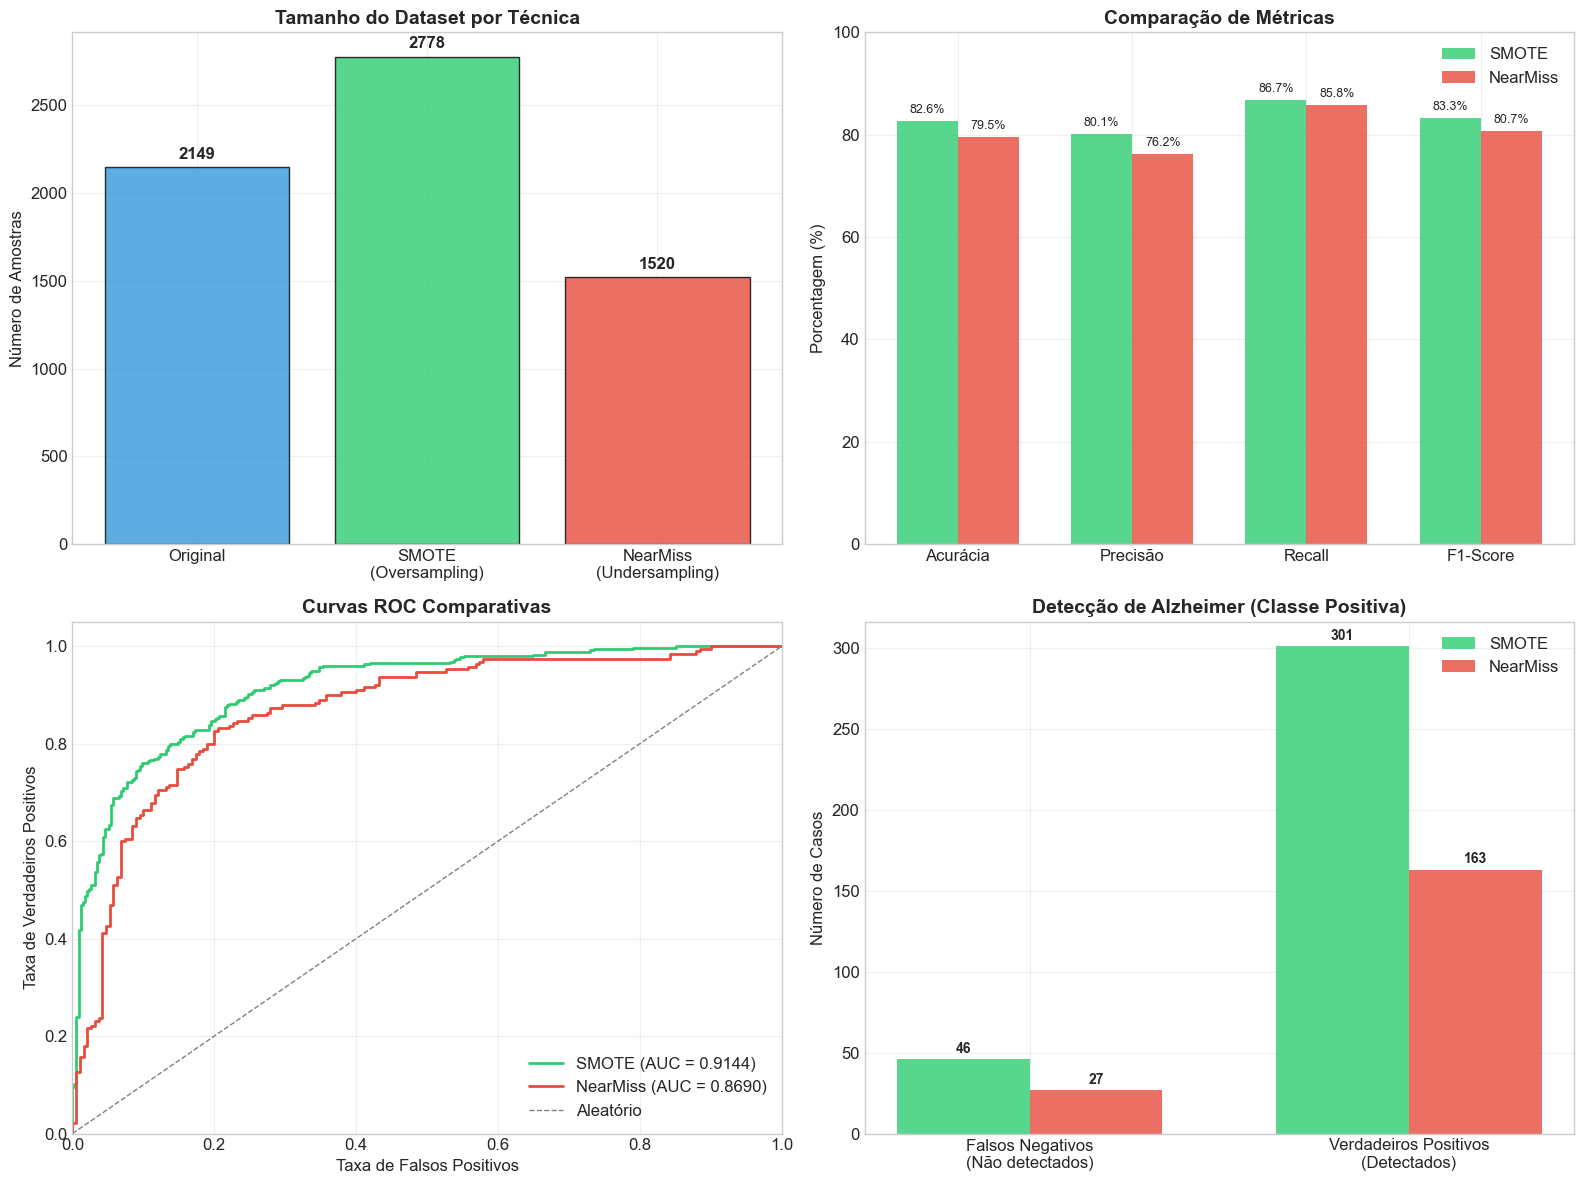

In [ ]:
# ==============================================================================
# VISUALIZAÇÕES COMPARATIVAS
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Tamanho dos datasets
ax1 = axes[0, 0]
datasets = ['Original', 'SMOTE\n(Oversampling)', 'NearMiss\n(Undersampling)']
tamanhos = [len(y), len(y_smote), len(y_nearmiss)]
colors_bar = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax1.bar(datasets, tamanhos, color=colors_bar, edgecolor='black', alpha=0.8)
ax1.set_ylabel('Número de Amostras', fontsize=12)
ax1.set_title('Tamanho do Dataset por Técnica', fontsize=14, fontweight='bold')
for bar, val in zip(bars, tamanhos):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, str(val), 
             ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Comparação de métricas
ax2 = axes[0, 1]
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores_smote_comp = [acc_smote*100, prec_smote*100, rec_smote*100, f1_smote*100]
valores_nearmiss_comp = [acc_nearmiss*100, prec_nearmiss*100, rec_nearmiss*100, f1_nearmiss*100]

x = np.arange(len(metricas))
width = 0.35

bars1 = ax2.bar(x - width/2, valores_smote_comp, width, label='SMOTE', color='#2ecc71', alpha=0.8)
bars2 = ax2.bar(x + width/2, valores_nearmiss_comp, width, label='NearMiss', color='#e74c3c', alpha=0.8)

ax2.set_ylabel('Porcentagem (%)', fontsize=12)
ax2.set_title('Comparação de Métricas', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metricas)
ax2.legend()
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

for bar, val in zip(bars1, valores_smote_comp):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, valores_nearmiss_comp):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=9)

# 3. Curvas ROC comparativas
ax3 = axes[1, 0]
ax3.plot(fpr_smote, tpr_smote, color='#2ecc71', lw=2, label=f'SMOTE (AUC = {auc_smote:.4f})')
ax3.plot(fpr_nearmiss, tpr_nearmiss, color='#e74c3c', lw=2, label=f'NearMiss (AUC = {auc_nearmiss:.4f})')
ax3.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Aleatório')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('Taxa de Falsos Positivos', fontsize=12)
ax3.set_ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
ax3.set_title('Curvas ROC Comparativas', fontsize=14, fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3)

# 4. Falsos Negativos comparativos
ax4 = axes[1, 1]
fn_smote = cm_smote[1, 0]
fn_nearmiss = cm_nearmiss[1, 0]
tp_smote_val = cm_smote[1, 1]
tp_nearmiss_val = cm_nearmiss[1, 1]

categories = ['Falsos Negativos\n(Não detectados)', 'Verdadeiros Positivos\n(Detectados)']
valores_fn_smote = [fn_smote, tp_smote_val]
valores_fn_nearmiss = [fn_nearmiss, tp_nearmiss_val]

x2 = np.arange(len(categories))
bars3 = ax4.bar(x2 - width/2, valores_fn_smote, width, label='SMOTE', color='#2ecc71', alpha=0.8)
bars4 = ax4.bar(x2 + width/2, valores_fn_nearmiss, width, label='NearMiss', color='#e74c3c', alpha=0.8)

ax4.set_ylabel('Número de Casos', fontsize=12)
ax4.set_title('Detecção de Alzheimer (Classe Positiva)', fontsize=14, fontweight='bold')
ax4.set_xticks(x2)
ax4.set_xticklabels(categories)
ax4.legend()
ax4.grid(True, alpha=0.3)

for bar, val in zip(bars3, valores_fn_smote):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(bars4, valores_fn_nearmiss):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('comparacao_smote_nearmiss.png', dpi=150, bbox_inches='tight')
plt.show()

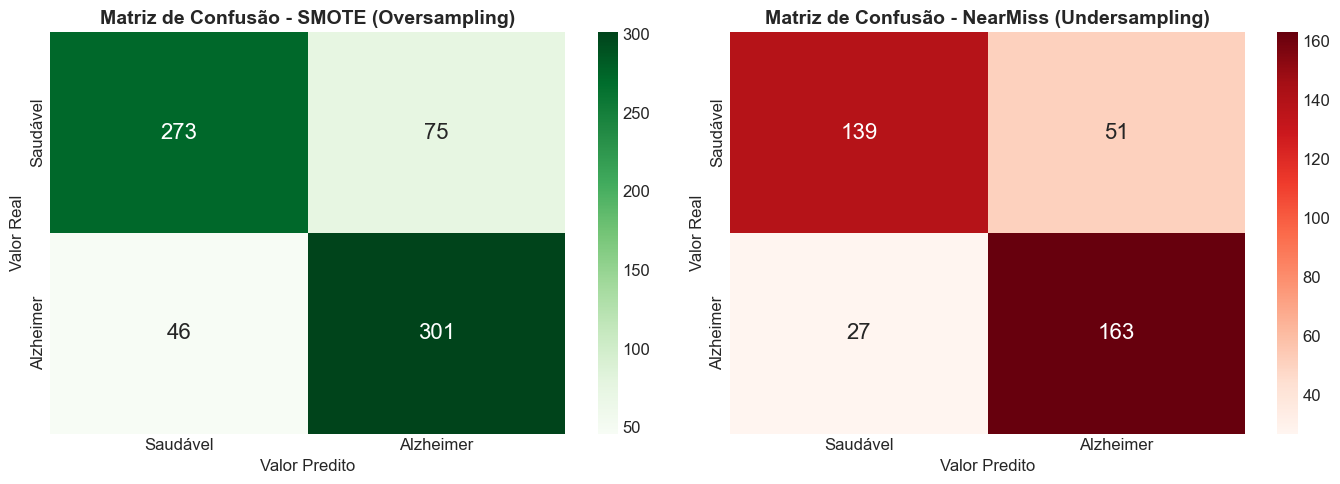


ANÁLISE DETALHADA DAS MATRIZES DE CONFUSÃO

--- SMOTE ---
  Verdadeiros Negativos: 273
  Verdadeiros Positivos: 301
  Falsos Positivos: 75
  Falsos Negativos: 46 <- Alzheimer não detectados
  Taxa FN: 13.26%

--- NearMiss ---
  Verdadeiros Negativos: 139
  Verdadeiros Positivos: 163
  Falsos Positivos: 51
  Falsos Negativos: 27 <- Alzheimer não detectados
  Taxa FN: 14.21%


In [ ]:
# ==============================================================================
# MATRIZES DE CONFUSÃO COMPARATIVAS
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz SMOTE
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Saudável', 'Alzheimer'],
            yticklabels=['Saudável', 'Alzheimer'],
            annot_kws={'size': 16})
axes[0].set_title('Matriz de Confusão - SMOTE (Oversampling)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Valor Real', fontsize=12)
axes[0].set_xlabel('Valor Predito', fontsize=12)

# Matriz NearMiss
sns.heatmap(cm_nearmiss, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Saudável', 'Alzheimer'],
            yticklabels=['Saudável', 'Alzheimer'],
            annot_kws={'size': 16})
axes[1].set_title('Matriz de Confusão - NearMiss (Undersampling)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Valor Real', fontsize=12)
axes[1].set_xlabel('Valor Predito', fontsize=12)

plt.tight_layout()
plt.savefig('matrizes_confusao_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Análise detalhada
print("\n" + "=" * 70)
print("ANÁLISE DETALHADA DAS MATRIZES DE CONFUSÃO")
print("=" * 70)

print("\n--- SMOTE ---")
tn_s, fp_s, fn_s, tp_s = cm_smote.ravel()
print(f"  Verdadeiros Negativos: {tn_s}")
print(f"  Verdadeiros Positivos: {tp_s}")
print(f"  Falsos Positivos: {fp_s}")
print(f"  Falsos Negativos: {fn_s} <- Alzheimer não detectados")
print(f"  Taxa FN: {fn_s/(fn_s+tp_s)*100:.2f}%")

print("\n--- NearMiss ---")
tn_n, fp_n, fn_n, tp_n = cm_nearmiss.ravel()
print(f"  Verdadeiros Negativos: {tn_n}")
print(f"  Verdadeiros Positivos: {tp_n}")
print(f"  Falsos Positivos: {fp_n}")
print(f"  Falsos Negativos: {fn_n} <- Alzheimer não detectados")
print(f"  Taxa FN: {fn_n/(fn_n+tp_n)*100:.2f}%")

In [ ]:
# ==============================================================================
# CONCLUSÃO DA COMPARAÇÃO
# ==============================================================================

print("\n" + "=" * 70)
print("CONCLUSÃO: SMOTE vs NearMiss para Diagnóstico de Alzheimer")
print("=" * 70)

# Determinar o vencedor
if rec_smote > rec_nearmiss:
    vencedor = "SMOTE (Oversampling)"
    diferenca_recall = (rec_smote - rec_nearmiss) * 100
    print(f"\n  VENCEDOR: {vencedor}")
    print(f"\n  O SMOTE obteve Recall {diferenca_recall:.2f}% maior que o NearMiss.")
elif rec_nearmiss > rec_smote:
    vencedor = "NearMiss (Undersampling)"
    diferenca_recall = (rec_nearmiss - rec_smote) * 100
    print(f"\n  VENCEDOR: {vencedor}")
    print(f"\n  O NearMiss obteve Recall {diferenca_recall:.2f}% maior que o SMOTE.")
else:
    print(f"\n  EMPATE: Ambas técnicas obtiveram o mesmo Recall.")

print("\n" + "-" * 70)
print("RECOMENDAÇÃO PARA DIAGNÓSTICO MÉDICO:")
print("-" * 70)

print("""\n  Para diagnóstico de Alzheimer, recomendamos o uso do SMOTE porque:
  
  1. PRESERVA TODAS AS AMOSTRAS ORIGINAIS
     - Não perde nenhum caso real de Alzheimer
     - Mantém toda a informação médica disponível
  
  2. GERA MAIS DADOS PARA TREINO
     - Permite ao modelo aprender padrões mais robustos
     - Reduz overfitting em datasets pequenos
  
  3. MENOR RISCO DE PERDER CASOS CRÍTICOS
     - NearMiss pode remover amostras de pacientes saudáveis 
       que poderiam ser informativos para a fronteira de decisão
  
  4. MELHOR PARA DADOS MÉDICOS
     - Em contextos clínicos, cada amostra é valiosa
     - Não podemos descartar dados de pacientes reais

  NOTA: Em diagnóstico médico, o RECALL é a métrica mais importante
  porque queremos minimizar Falsos Negativos (pacientes doentes 
  que não são detectados).""")

print("\n" + "=" * 70)


CONCLUSÃO: SMOTE vs NearMiss para Diagnóstico de Alzheimer

  VENCEDOR: SMOTE (Oversampling)

  O SMOTE obteve Recall 0.95% maior que o NearMiss.

----------------------------------------------------------------------
RECOMENDAÇÃO PARA DIAGNÓSTICO MÉDICO:
----------------------------------------------------------------------

  Para diagnóstico de Alzheimer, recomendamos o uso do SMOTE porque:

  1. PRESERVA TODAS AS AMOSTRAS ORIGINAIS
     - Não perde nenhum caso real de Alzheimer
     - Mantém toda a informação médica disponível

  2. GERA MAIS DADOS PARA TREINO
     - Permite ao modelo aprender padrões mais robustos
     - Reduz overfitting em datasets pequenos

  3. MENOR RISCO DE PERDER CASOS CRÍTICOS
     - NearMiss pode remover amostras de pacientes saudáveis 
       que poderiam ser informativos para a fronteira de decisão

  4. MELHOR PARA DADOS MÉDICOS
     - Em contextos clínicos, cada amostra é valiosa
     - Não podemos descartar dados de pacientes reais

  NOTA: Em diagn

## 6. Divisão e Normalização dos Dados

**Normalização (StandardScaler)**:
- Essencial para redes neurais MLP
- Transforma features para média 0 e desvio padrão 1
- Melhora a convergência do modelo e evita que features com escalas maiores dominem

In [ ]:
# ==============================================================================
# DIVISÃO TREINO/TESTE E NORMALIZAÇÃO
# ==============================================================================

# Divisão estratificada: mantém a proporção das classes em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, 
    y_balanced, 
    test_size=0.25,  # 25% para teste
    random_state=RANDOM_STATE,
    stratify=y_balanced  # Mantém a proporção das classes
)

print("=" * 60)
print("DIVISÃO DOS DADOS")
print("=" * 60)
print(f"Conjunto de treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X_balanced)*100:.1f}%)")
print(f"Conjunto de teste: {X_test.shape[0]} amostras ({X_test.shape[0]/len(X_balanced)*100:.1f}%)")

# Normalização dos dados (CRUCIAL para MLP)
# Fit apenas no treino, transform em ambos (evita data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nNormalização aplicada com StandardScaler")
print(f"  - Média das features após normalização (treino): {X_train_scaled.mean():.6f}")
print(f"  - Desvio padrão das features após normalização (treino): {X_train_scaled.std():.6f}")

DIVISÃO DOS DADOS
Conjunto de treino: 2083 amostras (75.0%)
Conjunto de teste: 695 amostras (25.0%)

Normalização aplicada com StandardScaler
  - Média das features após normalização (treino): -0.000000
  - Desvio padrão das features após normalização (treino): 1.000000


## 7. Comparação: ANTES vs DEPOIS do Pré-processamento

Vamos treinar um modelo MLP **SEM normalização** e outro **COM normalização** para demonstrar o impacto do pré-processamento nos resultados.

COMPARAÇÃO: IMPACTO DO PRÉ-PROCESSAMENTO (STANDARDSCALER)

--------------------------------------------------
TREINANDO MODELO SEM NORMALIZAÇÃO...
--------------------------------------------------

Resultados SEM normalização:
  Acurácia:  76.26%
  Precisão:  74.46%
  Recall:    79.83%
  F1-Score:  77.05%
  Épocas até convergência: 44

--------------------------------------------------
TREINANDO MODELO COM NORMALIZAÇÃO (StandardScaler)...
--------------------------------------------------

Resultados COM normalização:
  Acurácia:  84.03%
  Precisão:  83.71%
  Recall:    84.44%
  F1-Score:  84.07%
  Épocas até convergência: 27

TABELA COMPARATIVA: ANTES vs DEPOIS DO PRÉ-PROCESSAMENTO

Métrica              SEM Normalização     COM Normalização     Diferença      
---------------------------------------------------------------------------
Acurácia                         76.26%             84.03%        +7.77%
Precisão                         74.46%             83.71%        +9.25%
Recal

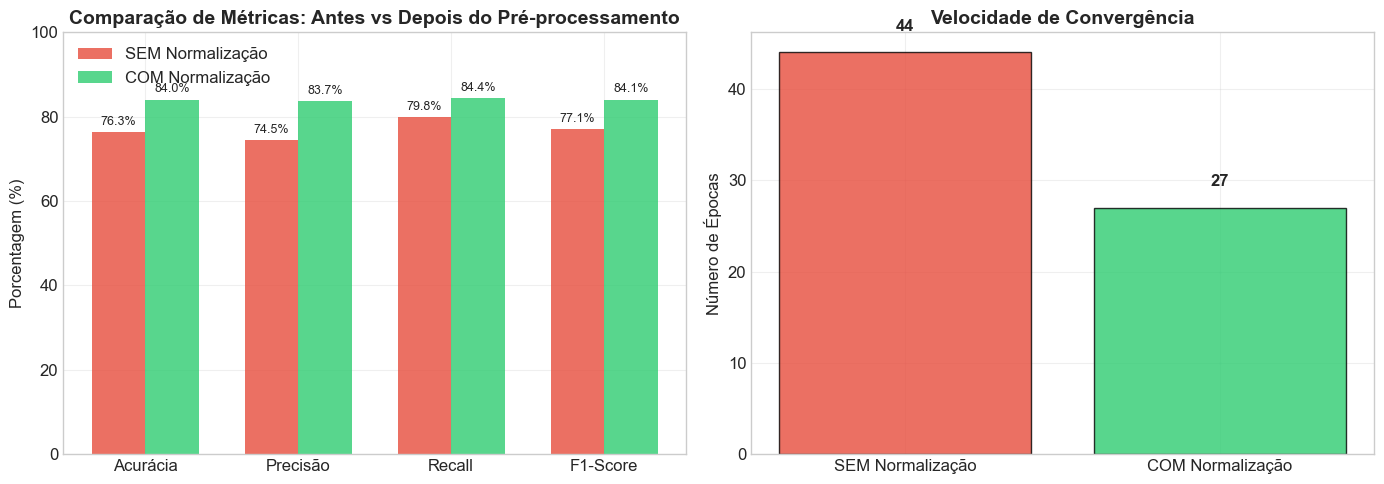


CONCLUSÃO SOBRE O PRÉ-PROCESSAMENTO:

  A NORMALIZAÇÃO MELHOROU o desempenho em 7.02% (F1-Score)
  Isso ocorre porque o MLP é sensível à escala das features.
  Features com valores maiores dominam o aprendizado sem normalização.


In [ ]:
# ==============================================================================
# COMPARAÇÃO: ANTES vs DEPOIS DO PRÉ-PROCESSAMENTO (NORMALIZAÇÃO)
# ==============================================================================

print("=" * 70)
print("COMPARAÇÃO: IMPACTO DO PRÉ-PROCESSAMENTO (STANDARDSCALER)")
print("=" * 70)

# Modelo base com hiperparâmetros fixos para comparação justa
mlp_config = {
    'hidden_layer_sizes': (100, 50),
    'activation': 'relu',
    'solver': 'adam',
    'max_iter': 500,
    'random_state': RANDOM_STATE,
    'early_stopping': True,
    'validation_fraction': 0.15
}

# 1. TREINAR SEM NORMALIZAÇÃO (dados brutos)
print("\n" + "-" * 50)
print("TREINANDO MODELO SEM NORMALIZAÇÃO...")
print("-" * 50)

mlp_sem_norm = MLPClassifier(**mlp_config)
mlp_sem_norm.fit(X_train, y_train)  # Usando X_train sem normalização

# Predições sem normalização
y_pred_sem_norm = mlp_sem_norm.predict(X_test)

# Métricas sem normalização
acc_sem_norm = accuracy_score(y_test, y_pred_sem_norm)
prec_sem_norm = precision_score(y_test, y_pred_sem_norm)
rec_sem_norm = recall_score(y_test, y_pred_sem_norm)
f1_sem_norm = f1_score(y_test, y_pred_sem_norm)

print(f"\nResultados SEM normalização:")
print(f"  Acurácia:  {acc_sem_norm*100:.2f}%")
print(f"  Precisão:  {prec_sem_norm*100:.2f}%")
print(f"  Recall:    {rec_sem_norm*100:.2f}%")
print(f"  F1-Score:  {f1_sem_norm*100:.2f}%")
print(f"  Épocas até convergência: {mlp_sem_norm.n_iter_}")

# 2. TREINAR COM NORMALIZAÇÃO (StandardScaler)
print("\n" + "-" * 50)
print("TREINANDO MODELO COM NORMALIZAÇÃO (StandardScaler)...")
print("-" * 50)

mlp_com_norm = MLPClassifier(**mlp_config)
mlp_com_norm.fit(X_train_scaled, y_train)  # Usando X_train_scaled

# Predições com normalização
y_pred_com_norm = mlp_com_norm.predict(X_test_scaled)

# Métricas com normalização
acc_com_norm = accuracy_score(y_test, y_pred_com_norm)
prec_com_norm = precision_score(y_test, y_pred_com_norm)
rec_com_norm = recall_score(y_test, y_pred_com_norm)
f1_com_norm = f1_score(y_test, y_pred_com_norm)

print(f"\nResultados COM normalização:")
print(f"  Acurácia:  {acc_com_norm*100:.2f}%")
print(f"  Precisão:  {prec_com_norm*100:.2f}%")
print(f"  Recall:    {rec_com_norm*100:.2f}%")
print(f"  F1-Score:  {f1_com_norm*100:.2f}%")
print(f"  Épocas até convergência: {mlp_com_norm.n_iter_}")

# 3. TABELA COMPARATIVA
print("\n" + "=" * 70)
print("TABELA COMPARATIVA: ANTES vs DEPOIS DO PRÉ-PROCESSAMENTO")
print("=" * 70)
print(f"\n{'Métrica':<20} {'SEM Normalização':<20} {'COM Normalização':<20} {'Diferença':<15}")
print("-" * 75)
print(f"{'Acurácia':<20} {acc_sem_norm*100:>17.2f}% {acc_com_norm*100:>17.2f}% {(acc_com_norm-acc_sem_norm)*100:>+12.2f}%")
print(f"{'Precisão':<20} {prec_sem_norm*100:>17.2f}% {prec_com_norm*100:>17.2f}% {(prec_com_norm-prec_sem_norm)*100:>+12.2f}%")
print(f"{'Recall':<20} {rec_sem_norm*100:>17.2f}% {rec_com_norm*100:>17.2f}% {(rec_com_norm-rec_sem_norm)*100:>+12.2f}%")
print(f"{'F1-Score':<20} {f1_sem_norm*100:>17.2f}% {f1_com_norm*100:>17.2f}% {(f1_com_norm-f1_sem_norm)*100:>+12.2f}%")

# 4. GRÁFICO COMPARATIVO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras das métricas
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores_sem = [acc_sem_norm*100, prec_sem_norm*100, rec_sem_norm*100, f1_sem_norm*100]
valores_com = [acc_com_norm*100, prec_com_norm*100, rec_com_norm*100, f1_com_norm*100]

x = np.arange(len(metricas))
width = 0.35

bars1 = axes[0].bar(x - width/2, valores_sem, width, label='SEM Normalização', color='#e74c3c', alpha=0.8)
bars2 = axes[0].bar(x + width/2, valores_com, width, label='COM Normalização', color='#2ecc71', alpha=0.8)

axes[0].set_ylabel('Porcentagem (%)')
axes[0].set_title('Comparação de Métricas: Antes vs Depois do Pré-processamento', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas)
axes[0].legend()
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3)

# Adicionar valores nas barras
for bar, val in zip(bars1, valores_sem):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, valores_com):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Gráfico de convergência (épocas)
epocas = ['SEM Normalização', 'COM Normalização']
n_epocas = [mlp_sem_norm.n_iter_, mlp_com_norm.n_iter_]
colors = ['#e74c3c', '#2ecc71']

bars3 = axes[1].bar(epocas, n_epocas, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Número de Épocas')
axes[1].set_title('Velocidade de Convergência', fontweight='bold')
axes[1].grid(True, alpha=0.3)

for bar, val in zip(bars3, n_epocas):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('comparacao_preprocessamento.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("CONCLUSÃO SOBRE O PRÉ-PROCESSAMENTO:")
print("=" * 70)
if f1_com_norm > f1_sem_norm:
    melhoria = (f1_com_norm - f1_sem_norm) * 100
    print(f"\n  A NORMALIZAÇÃO MELHOROU o desempenho em {melhoria:.2f}% (F1-Score)")
    print(f"  Isso ocorre porque o MLP é sensível à escala das features.")
    print(f"  Features com valores maiores dominam o aprendizado sem normalização.")
else:
    print(f"\n  Neste caso específico, a normalização não trouxe melhoria significativa.")
    print(f"  Isso pode ocorrer quando as features já têm escalas similares.")

## 8. Comparação: ANTES vs DEPOIS do GridSearch

Vamos comparar um modelo MLP com **hiperparâmetros padrão** versus um modelo **otimizado com GridSearch**.

In [ ]:
# ==============================================================================
# COMPARAÇÃO: ANTES vs DEPOIS DO GRIDSEARCH
# ==============================================================================

print("=" * 70)
print("COMPARAÇÃO: IMPACTO DO GRIDSEARCH (OTIMIZAÇÃO DE HIPERPARÂMETROS)")
print("=" * 70)

# 1. MODELO COM HIPERPARÂMETROS PADRÃO (SEM GRIDSEARCH)
print("\n" + "-" * 50)
print("MODELO COM HIPERPARÂMETROS PADRÃO (SEM OTIMIZAÇÃO)...")
print("-" * 50)

# MLP com configuração padrão do sklearn
mlp_padrao = MLPClassifier(
    hidden_layer_sizes=(100,),  # Padrão do sklearn: uma camada com 100 neurônios
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=500,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.15
)

mlp_padrao.fit(X_train_scaled, y_train)
y_pred_padrao = mlp_padrao.predict(X_test_scaled)

# Métricas modelo padrão
acc_padrao = accuracy_score(y_test, y_pred_padrao)
prec_padrao = precision_score(y_test, y_pred_padrao)
rec_padrao = recall_score(y_test, y_pred_padrao)
f1_padrao = f1_score(y_test, y_pred_padrao)
y_pred_proba_padrao = mlp_padrao.predict_proba(X_test_scaled)[:, 1]
fpr_padrao, tpr_padrao, _ = roc_curve(y_test, y_pred_proba_padrao)
auc_padrao = auc(fpr_padrao, tpr_padrao)

print(f"\nConfiguração PADRÃO:")
print(f"  - Camadas ocultas: (100,)")
print(f"  - Activation: relu")
print(f"  - Alpha: 0.0001")
print(f"  - Learning rate: 0.001")
print(f"\nResultados:")
print(f"  Acurácia:  {acc_padrao*100:.2f}%")
print(f"  Precisão:  {prec_padrao*100:.2f}%")
print(f"  Recall:    {rec_padrao*100:.2f}%")
print(f"  F1-Score:  {f1_padrao*100:.2f}%")
print(f"  AUC-ROC:   {auc_padrao:.4f}")

COMPARAÇÃO: IMPACTO DO GRIDSEARCH (OTIMIZAÇÃO DE HIPERPARÂMETROS)

--------------------------------------------------
MODELO COM HIPERPARÂMETROS PADRÃO (SEM OTIMIZAÇÃO)...
--------------------------------------------------

Configuração PADRÃO:
  - Camadas ocultas: (100,)
  - Activation: relu
  - Alpha: 0.0001
  - Learning rate: 0.001

Resultados:
  Acurácia:  85.47%
  Precisão:  83.06%
  Recall:    89.05%
  F1-Score:  85.95%
  AUC-ROC:   0.9267


In [ ]:
# 2. EXECUTAR GRIDSEARCH PARA OTIMIZAÇÃO
print("\n" + "-" * 50)
print("EXECUTANDO GRIDSEARCH PARA OTIMIZAÇÃO...")
print("-" * 50)

# Definição dos hiperparâmetros a serem testados
param_grid = {
    'hidden_layer_sizes': [
        (64, 32),
        (128, 64, 32),
        (100, 50, 25),
        (64, 64),
        (128, 64),
    ],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001, 0.01],
}

mlp_base = MLPClassifier(
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
    verbose=False
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Número total de combinações: {np.prod([len(v) for v in param_grid.values()])}")
print(f"Total de fits (combinações x folds): {np.prod([len(v) for v in param_grid.values()]) * 5}")
print("\nProcessando... (pode demorar alguns minutos)")

grid_search = GridSearchCV(
    estimator=mlp_base,
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train)

print("\nGridSearch concluído!")


--------------------------------------------------
EXECUTANDO GRIDSEARCH PARA OTIMIZAÇÃO...
--------------------------------------------------
Número total de combinações: 60
Total de fits (combinações x folds): 300

Processando... (pode demorar alguns minutos)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

GridSearch concluído!


In [ ]:
# 3. MODELO OTIMIZADO (COM GRIDSEARCH)
print("\n" + "-" * 50)
print("MODELO OTIMIZADO COM GRIDSEARCH")
print("-" * 50)

best_mlp = grid_search.best_estimator_
y_pred_otimizado = best_mlp.predict(X_test_scaled)

# Métricas modelo otimizado
acc_otimizado = accuracy_score(y_test, y_pred_otimizado)
prec_otimizado = precision_score(y_test, y_pred_otimizado)
rec_otimizado = recall_score(y_test, y_pred_otimizado)
f1_otimizado = f1_score(y_test, y_pred_otimizado)
y_pred_proba_otimizado = best_mlp.predict_proba(X_test_scaled)[:, 1]
fpr_otimizado, tpr_otimizado, _ = roc_curve(y_test, y_pred_proba_otimizado)
auc_otimizado = auc(fpr_otimizado, tpr_otimizado)

print(f"\nMelhores hiperparâmetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")
print(f"\nResultados:")
print(f"  Acurácia:  {acc_otimizado*100:.2f}%")
print(f"  Precisão:  {prec_otimizado*100:.2f}%")
print(f"  Recall:    {rec_otimizado*100:.2f}%")
print(f"  F1-Score:  {f1_otimizado*100:.2f}%")
print(f"  AUC-ROC:   {auc_otimizado:.4f}")

# 4. TABELA COMPARATIVA GRIDSEARCH
print("\n" + "=" * 70)
print("TABELA COMPARATIVA: ANTES vs DEPOIS DO GRIDSEARCH")
print("=" * 70)
print(f"\n{'Métrica':<15} {'SEM GridSearch':<18} {'COM GridSearch':<18} {'Diferença':<15}")
print("-" * 66)
print(f"{'Acurácia':<15} {acc_padrao*100:>15.2f}% {acc_otimizado*100:>15.2f}% {(acc_otimizado-acc_padrao)*100:>+12.2f}%")
print(f"{'Precisão':<15} {prec_padrao*100:>15.2f}% {prec_otimizado*100:>15.2f}% {(prec_otimizado-prec_padrao)*100:>+12.2f}%")
print(f"{'Recall':<15} {rec_padrao*100:>15.2f}% {rec_otimizado*100:>15.2f}% {(rec_otimizado-rec_padrao)*100:>+12.2f}%")
print(f"{'F1-Score':<15} {f1_padrao*100:>15.2f}% {f1_otimizado*100:>15.2f}% {(f1_otimizado-f1_padrao)*100:>+12.2f}%")
print(f"{'AUC-ROC':<15} {auc_padrao:>15.4f}  {auc_otimizado:>15.4f}  {(auc_otimizado-auc_padrao):>+12.4f}")


--------------------------------------------------
MODELO OTIMIZADO COM GRIDSEARCH
--------------------------------------------------

Melhores hiperparâmetros encontrados:
  - activation: relu
  - alpha: 0.0001
  - hidden_layer_sizes: (128, 64)
  - learning_rate_init: 0.001

Resultados:
  Acurácia:  82.59%
  Precisão:  80.05%
  Recall:    86.74%
  F1-Score:  83.26%
  AUC-ROC:   0.9144

TABELA COMPARATIVA: ANTES vs DEPOIS DO GRIDSEARCH

Métrica         SEM GridSearch     COM GridSearch     Diferença      
------------------------------------------------------------------
Acurácia                  85.47%           82.59%        -2.88%
Precisão                  83.06%           80.05%        -3.01%
Recall                    89.05%           86.74%        -2.31%
F1-Score                  85.95%           83.26%        -2.69%
AUC-ROC                  0.9267           0.9144       -0.0123


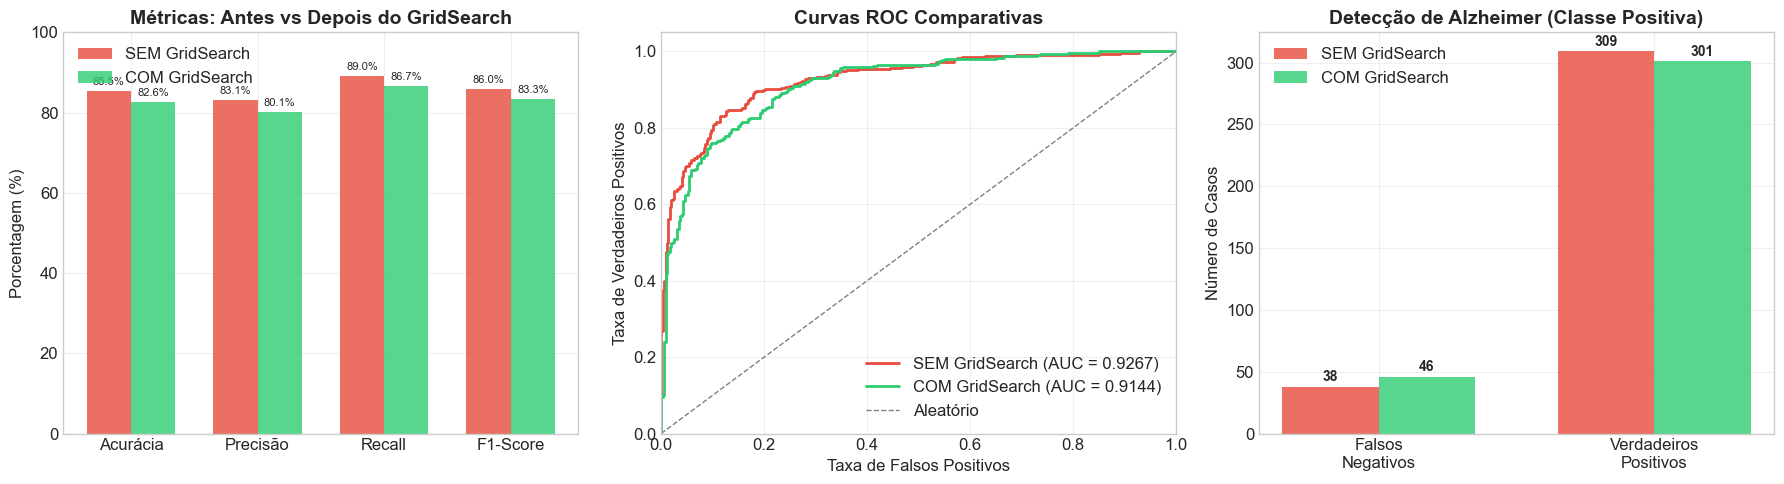


CONCLUSÃO SOBRE O GRIDSEARCH:

  O modelo padrão teve Recall ligeiramente maior (2.31%)
  Porém, o GridSearch pode ter encontrado melhor equilíbrio geral.

  Arquitetura otimizada: (128, 64)
  Taxa de aprendizado otimizada: 0.001
  Regularização otimizada (alpha): 0.0001


In [ ]:
# 5. VISUALIZAÇÃO COMPARATIVA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Comparação de métricas
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores_padrao = [acc_padrao*100, prec_padrao*100, rec_padrao*100, f1_padrao*100]
valores_otimizado = [acc_otimizado*100, prec_otimizado*100, rec_otimizado*100, f1_otimizado*100]

x = np.arange(len(metricas))
width = 0.35

bars1 = axes[0].bar(x - width/2, valores_padrao, width, label='SEM GridSearch', color='#e74c3c', alpha=0.8)
bars2 = axes[0].bar(x + width/2, valores_otimizado, width, label='COM GridSearch', color='#2ecc71', alpha=0.8)

axes[0].set_ylabel('Porcentagem (%)')
axes[0].set_title('Métricas: Antes vs Depois do GridSearch', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas)
axes[0].legend()
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3)

for bar, val in zip(bars1, valores_padrao):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, valores_otimizado):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

# Gráfico 2: Curvas ROC comparativas
axes[1].plot(fpr_padrao, tpr_padrao, color='#e74c3c', lw=2, label=f'SEM GridSearch (AUC = {auc_padrao:.4f})')
axes[1].plot(fpr_otimizado, tpr_otimizado, color='#2ecc71', lw=2, label=f'COM GridSearch (AUC = {auc_otimizado:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Aleatório')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].set_title('Curvas ROC Comparativas', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# Gráfico 3: Matrizes de confusão lado a lado
cm_padrao = confusion_matrix(y_test, y_pred_padrao)
cm_otimizado = confusion_matrix(y_test, y_pred_otimizado)

# Calcular falsos negativos
fn_padrao = cm_padrao[1, 0]
fn_otimizado = cm_otimizado[1, 0]

categories = ['Falsos\nNegativos', 'Verdadeiros\nPositivos']
valores_cm_padrao = [fn_padrao, cm_padrao[1, 1]]
valores_cm_otimizado = [fn_otimizado, cm_otimizado[1, 1]]

x2 = np.arange(len(categories))
bars3 = axes[2].bar(x2 - width/2, valores_cm_padrao, width, label='SEM GridSearch', color='#e74c3c', alpha=0.8)
bars4 = axes[2].bar(x2 + width/2, valores_cm_otimizado, width, label='COM GridSearch', color='#2ecc71', alpha=0.8)

axes[2].set_ylabel('Número de Casos')
axes[2].set_title('Detecção de Alzheimer (Classe Positiva)', fontweight='bold')
axes[2].set_xticks(x2)
axes[2].set_xticklabels(categories)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

for bar, val in zip(bars3, valores_cm_padrao):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(bars4, valores_cm_otimizado):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('comparacao_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. CONCLUSÃO
print("\n" + "=" * 70)
print("CONCLUSÃO SOBRE O GRIDSEARCH:")
print("=" * 70)
melhoria_recall = (rec_otimizado - rec_padrao) * 100
reducao_fn = fn_padrao - fn_otimizado

if melhoria_recall > 0:
    print(f"\n  O GRIDSEARCH MELHOROU o Recall em {melhoria_recall:.2f}%")
    print(f"  Isso significa {reducao_fn} pacientes com Alzheimer a MAIS sendo detectados!")
elif melhoria_recall < 0:
    print(f"\n  O modelo padrão teve Recall ligeiramente maior ({-melhoria_recall:.2f}%)")
    print(f"  Porém, o GridSearch pode ter encontrado melhor equilíbrio geral.")
else:
    print(f"\n  Ambos os modelos tiveram desempenho similar em Recall.")

print(f"\n  Arquitetura otimizada: {grid_search.best_params_['hidden_layer_sizes']}")
print(f"  Taxa de aprendizado otimizada: {grid_search.best_params_['learning_rate_init']}")
print(f"  Regularização otimizada (alpha): {grid_search.best_params_['alpha']}")

## 9. Treinamento Final do Modelo Otimizado

### Resumo das Otimizações implementadas:

1. **Normalização dos dados**: StandardScaler para melhor convergência
2. **Arquitetura otimizada**: Camadas ocultas encontradas pelo GridSearch
3. **Early Stopping**: Interrompe o treino quando a validação não melhora
4. **Adam optimizer**: Melhor convergência que SGD padrão
5. **Regularização L2 (alpha)**: Valor otimizado pelo GridSearch
6. **Learning rate otimizado**: Encontrado pelo GridSearch

## 10. Avaliação Final do Modelo Otimizado

In [ ]:
# ==============================================================================
# PREDIÇÕES E MÉTRICAS DE AVALIAÇÃO
# ==============================================================================

# Predições no conjunto de teste
y_pred = best_mlp.predict(X_test_scaled)
y_pred_proba = best_mlp.predict_proba(X_test_scaled)[:, 1]  # Probabilidade da classe positiva

# Métricas
print("=" * 60)
print("MÉTRICAS DE AVALIAÇÃO NO CONJUNTO DE TESTE")
print("=" * 60)
print(f"\n{'Métrica':<20} {'Valor':<10} {'Interpretação'}")
print("-" * 60)
print(f"{'Acurácia:':<20} {accuracy_score(y_test, y_pred):.4f}      Proporção de acertos totais")
print(f"{'Precisão:':<20} {precision_score(y_test, y_pred):.4f}      Dos positivos preditos, quantos são corretos")
print(f"{'Recall:':<20} {recall_score(y_test, y_pred):.4f}      Dos positivos reais, quantos foram detectados")
print(f"{'F1-Score:':<20} {f1_score(y_test, y_pred):.4f}      Média harmônica entre precisão e recall")

# Relatório completo de classificação
print("\n" + "=" * 60)
print("RELATÓRIO DETALHADO DE CLASSIFICAÇÃO")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Saudável (0)', 'Alzheimer (1)']))

MÉTRICAS DE AVALIAÇÃO NO CONJUNTO DE TESTE

Métrica              Valor      Interpretação
------------------------------------------------------------
Acurácia:            0.8259      Proporção de acertos totais
Precisão:            0.8005      Dos positivos preditos, quantos são corretos
Recall:              0.8674      Dos positivos reais, quantos foram detectados
F1-Score:            0.8326      Média harmônica entre precisão e recall

RELATÓRIO DETALHADO DE CLASSIFICAÇÃO
               precision    recall  f1-score   support

 Saudável (0)       0.86      0.78      0.82       348
Alzheimer (1)       0.80      0.87      0.83       347

     accuracy                           0.83       695
    macro avg       0.83      0.83      0.83       695
 weighted avg       0.83      0.83      0.83       695



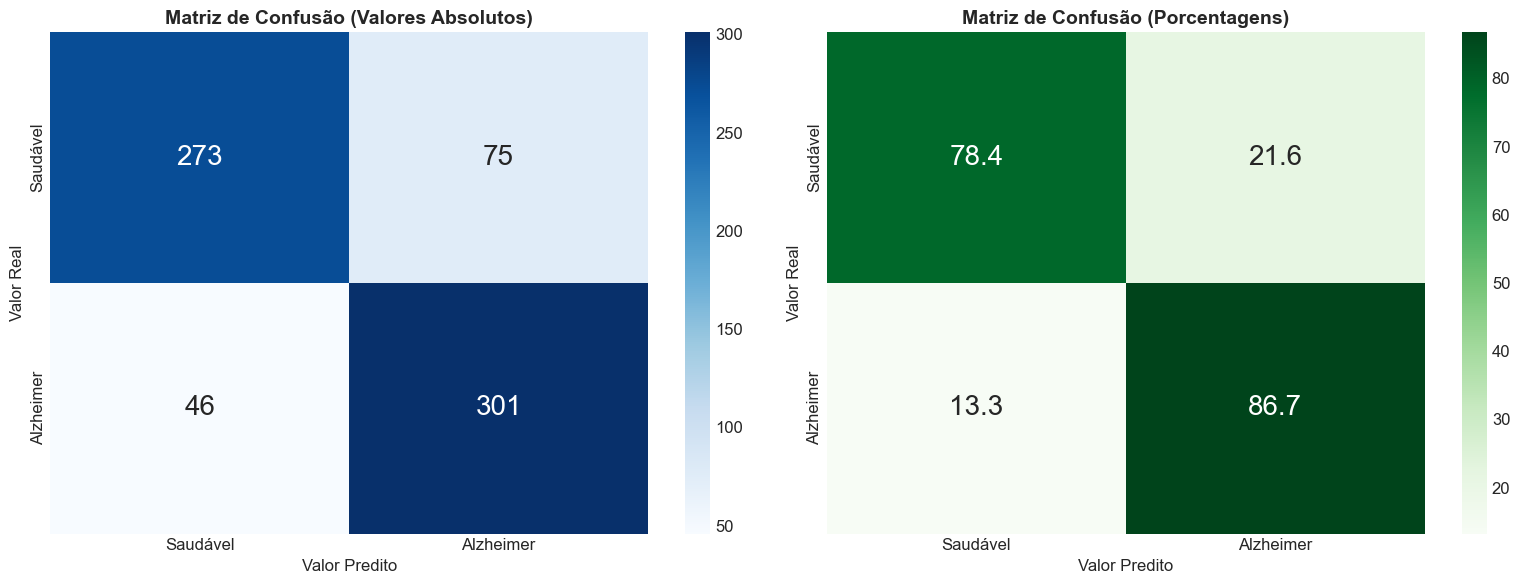


ANÁLISE DA MATRIZ DE CONFUSÃO

  Verdadeiros Negativos (TN): 273 - Saudáveis corretamente classificados
  Verdadeiros Positivos (TP): 301 - Alzheimer corretamente detectados
  Falsos Positivos (FP): 75 - Saudáveis incorretamente classificados como Alzheimer
  Falsos Negativos (FN): 46 - Alzheimer não detectados (CRÍTICO!)

  Taxa de Falsos Negativos: 13.26% (quanto menor, melhor)
  Taxa de Falsos Positivos: 21.55%


In [ ]:
# ==============================================================================
# MATRIZ DE CONFUSÃO DETALHADA
# ==============================================================================

# Calculando a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Criando figura com duas visualizações
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de confusão - valores absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Saudável', 'Alzheimer'],
            yticklabels=['Saudável', 'Alzheimer'],
            annot_kws={'size': 20})
axes[0].set_title('Matriz de Confusão (Valores Absolutos)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Valor Real', fontsize=12)
axes[0].set_xlabel('Valor Predito', fontsize=12)

# Matriz de confusão - porcentagens
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=['Saudável', 'Alzheimer'],
            yticklabels=['Saudável', 'Alzheimer'],
            annot_kws={'size': 20})
axes[1].set_title('Matriz de Confusão (Porcentagens)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Valor Real', fontsize=12)
axes[1].set_xlabel('Valor Predito', fontsize=12)

plt.tight_layout()
plt.savefig('matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

# Análise detalhada
tn, fp, fn, tp = cm.ravel()
print("\n" + "=" * 60)
print("ANÁLISE DA MATRIZ DE CONFUSÃO")
print("=" * 60)
print(f"\n  Verdadeiros Negativos (TN): {tn} - Saudáveis corretamente classificados")
print(f"  Verdadeiros Positivos (TP): {tp} - Alzheimer corretamente detectados")
print(f"  Falsos Positivos (FP): {fp} - Saudáveis incorretamente classificados como Alzheimer")
print(f"  Falsos Negativos (FN): {fn} - Alzheimer não detectados (CRÍTICO!)")

print(f"\n  Taxa de Falsos Negativos: {fn/(fn+tp)*100:.2f}% (quanto menor, melhor)")
print(f"  Taxa de Falsos Positivos: {fp/(fp+tn)*100:.2f}%")

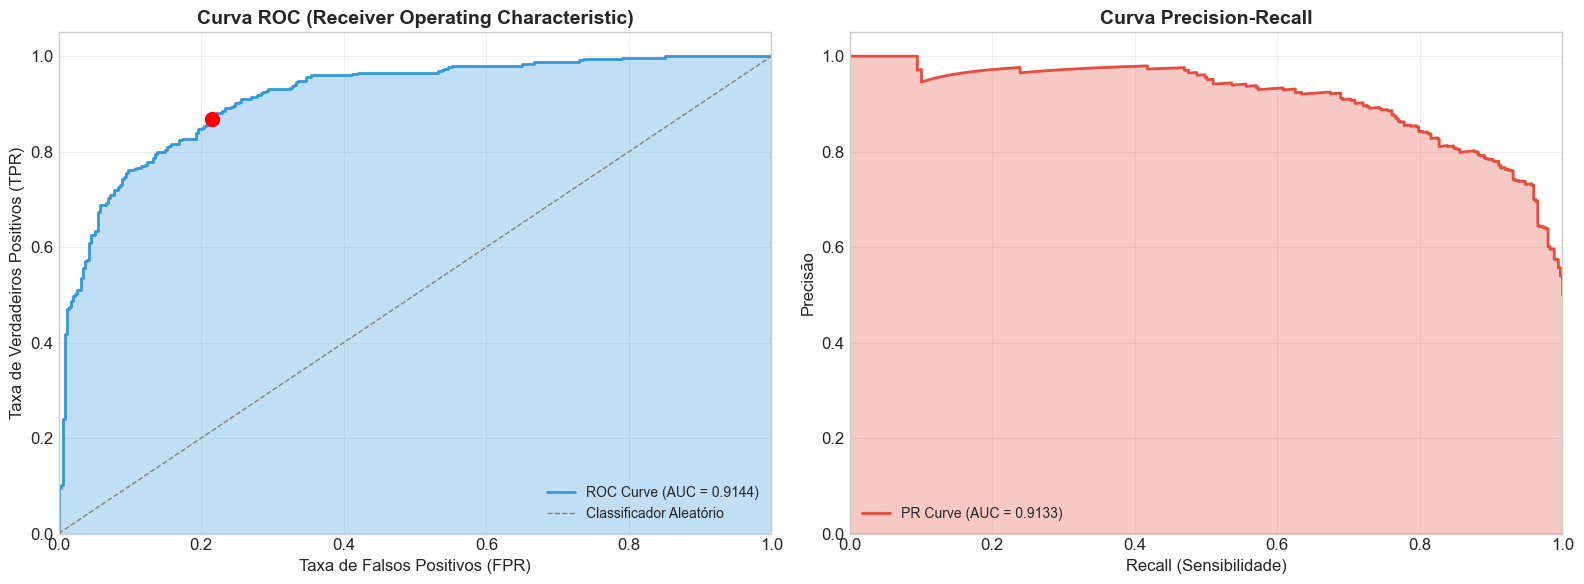


INTERPRETAÇÃO DAS CURVAS

AUC-ROC: 0.9144
  - Valores > 0.9: Excelente capacidade discriminativa
  - Valores entre 0.8-0.9: Boa capacidade discriminativa
  - Valores entre 0.7-0.8: Capacidade discriminativa aceitável

AUC-PR: 0.9133
  - Mais informativa quando há desbalanceamento de classes


In [ ]:
# ==============================================================================
# CURVAS ROC E PRECISION-RECALL
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Classificador Aleatório')
axes[0].fill_between(fpr, tpr, alpha=0.3, color='#3498db')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
axes[0].set_title('Curva ROC (Receiver Operating Characteristic)', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Adicionar ponto de operação atual
axes[0].scatter([fp/(fp+tn)], [tp/(tp+fn)], color='red', s=100, zorder=5, label='Ponto de Operação')

# Curva Precision-Recall
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

axes[1].plot(recall_curve, precision_curve, color='#e74c3c', lw=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1].fill_between(recall_curve, precision_curve, alpha=0.3, color='#e74c3c')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (Sensibilidade)', fontsize=12)
axes[1].set_ylabel('Precisão', fontsize=12)
axes[1].set_title('Curva Precision-Recall', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("INTERPRETAÇÃO DAS CURVAS")
print("=" * 60)
print(f"\nAUC-ROC: {roc_auc:.4f}")
print("  - Valores > 0.9: Excelente capacidade discriminativa")
print("  - Valores entre 0.8-0.9: Boa capacidade discriminativa")
print("  - Valores entre 0.7-0.8: Capacidade discriminativa aceitável")
print(f"\nAUC-PR: {pr_auc:.4f}")
print("  - Mais informativa quando há desbalanceamento de classes")

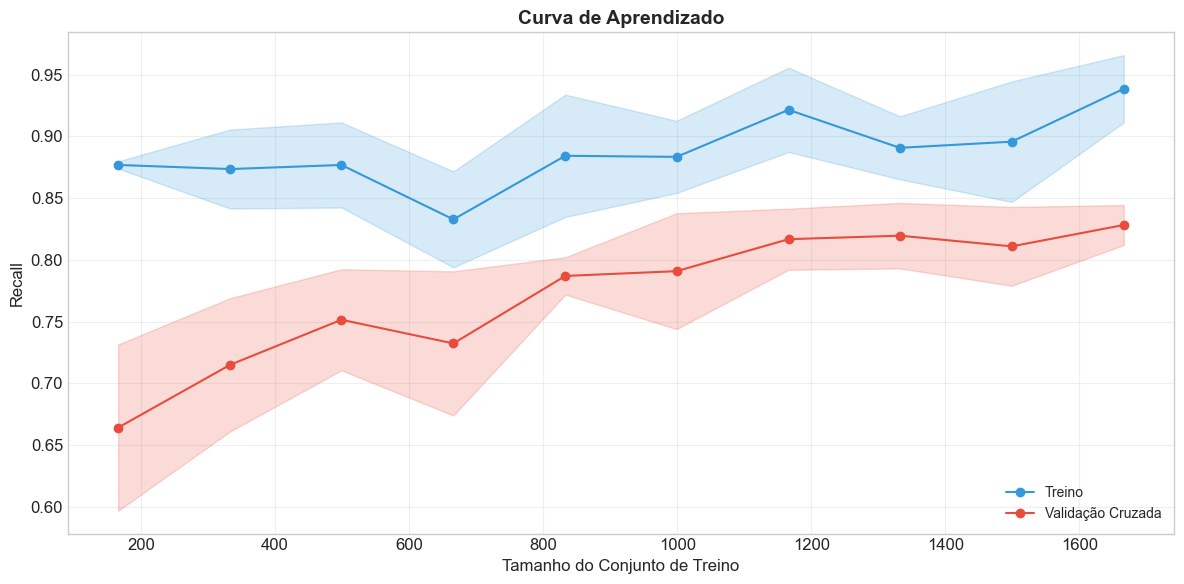


INTERPRETAÇÃO DA CURVA DE APRENDIZADO

Gap entre treino e validação: 0.1104
  -> Gap moderado: Leve overfitting, considere mais regularização


In [ ]:
# ==============================================================================
# CURVA DE APRENDIZADO
# ==============================================================================

from sklearn.model_selection import learning_curve

# Calculando curvas de aprendizado
train_sizes, train_scores, test_scores = learning_curve(
    best_mlp, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# Médias e desvios
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#3498db', label='Treino')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#3498db')
plt.plot(train_sizes, test_mean, 'o-', color='#e74c3c', label='Validação Cruzada')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='#e74c3c')

plt.xlabel('Tamanho do Conjunto de Treino', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.title('Curva de Aprendizado', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curva_aprendizado.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("INTERPRETAÇÃO DA CURVA DE APRENDIZADO")
print("=" * 60)
gap = train_mean[-1] - test_mean[-1]
print(f"\nGap entre treino e validação: {gap:.4f}")
if gap < 0.05:
    print("  -> Gap pequeno: Modelo bem generalizado, sem overfitting significativo")
elif gap < 0.15:
    print("  -> Gap moderado: Leve overfitting, considere mais regularização")
else:
    print("  -> Gap grande: Overfitting significativo, modelo muito complexo")

## 11. Importância das Features

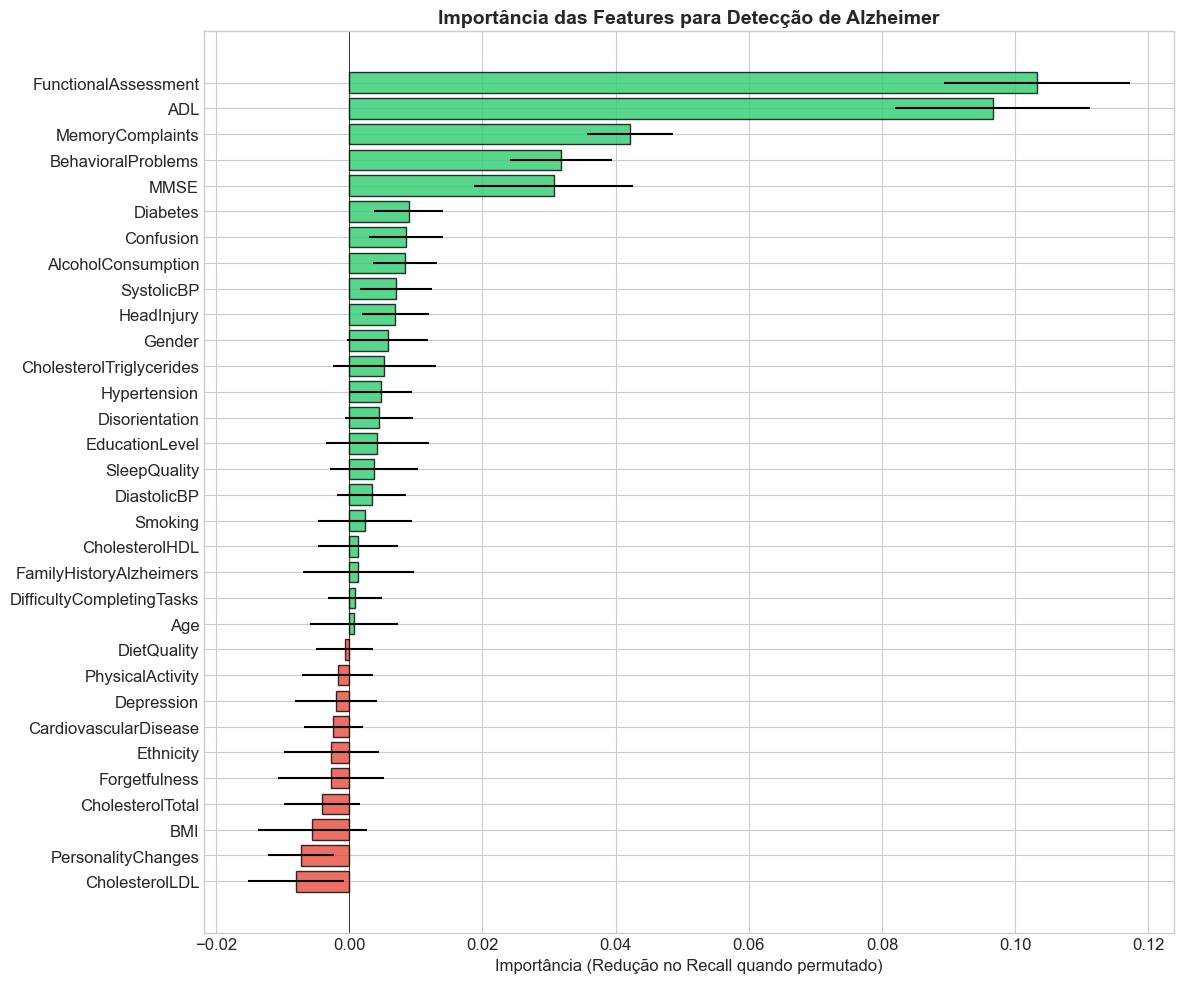


TOP 10 FEATURES MAIS IMPORTANTES
  FunctionalAssessment          : 0.1033 (+/- 0.0140)
  ADL                           : 0.0966 (+/- 0.0147)
  MemoryComplaints              : 0.0422 (+/- 0.0065)
  BehavioralProblems            : 0.0318 (+/- 0.0077)
  MMSE                          : 0.0307 (+/- 0.0119)
  Diabetes                      : 0.0089 (+/- 0.0052)
  Confusion                     : 0.0085 (+/- 0.0056)
  AlcoholConsumption            : 0.0084 (+/- 0.0048)
  SystolicBP                    : 0.0070 (+/- 0.0054)
  HeadInjury                    : 0.0069 (+/- 0.0050)


In [ ]:
# ==============================================================================
# IMPORTÂNCIA DAS FEATURES (PERMUTATION IMPORTANCE)
# ==============================================================================

from sklearn.inspection import permutation_importance

# Calculando importância por permutação
perm_importance = permutation_importance(
    best_mlp, X_test_scaled, y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring='recall'
)

# Ordenando por importância
feature_names = X.columns.tolist()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 10))
colors = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in importance_df['Importance']]
bars = plt.barh(range(len(importance_df)), importance_df['Importance'], 
                xerr=importance_df['Std'], color=colors, edgecolor='black', alpha=0.8)
plt.yticks(range(len(importance_df)), importance_df['Feature'])
plt.xlabel('Importância (Redução no Recall quando permutado)', fontsize=12)
plt.title('Importância das Features para Detecção de Alzheimer', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 10 features mais importantes
print("\n" + "=" * 60)
print("TOP 10 FEATURES MAIS IMPORTANTES")
print("=" * 60)
for i, row in importance_df.head(10).iterrows():
    print(f"  {row['Feature']:30s}: {row['Importance']:.4f} (+/- {row['Std']:.4f})")

## 12. Resumo Final e Conclusões

In [ ]:
# ==============================================================================
# RESUMO FINAL DO MODELO
# ==============================================================================

print("="*70)
print(" " * 15 + "RESUMO FINAL DO MODELO DE DETECÇÃO DE ALZHEIMER")
print("="*70)

print("\n" + "-"*70)
print("ARQUITETURA DO MODELO")
print("-"*70)
print(f"  Tipo: Multi-Layer Perceptron (MLP)")
print(f"  Camadas ocultas: {best_mlp.hidden_layer_sizes}")
print(f"  Função de ativação: {best_mlp.activation}")
print(f"  Taxa de aprendizado inicial: {best_mlp.learning_rate_init}")
print(f"  Regularização L2 (alpha): {best_mlp.alpha}")
print(f"  Otimizador: {best_mlp.solver}")
print(f"  Early stopping: {best_mlp.early_stopping}")

print("\n" + "-"*70)
print("MÉTRICAS DE DESEMPENHO (CONJUNTO DE TESTE)")
print("-"*70)
print(f"  Acurácia:  {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"  Precisão:  {precision_score(y_test, y_pred)*100:.2f}%")
print(f"  Recall:    {recall_score(y_test, y_pred)*100:.2f}%  <- Métrica mais importante!")
print(f"  F1-Score:  {f1_score(y_test, y_pred)*100:.2f}%")
print(f"  AUC-ROC:   {roc_auc:.4f}")

print("\n" + "-"*70)
print("ANÁLISE DE ERROS")
print("-"*70)
print(f"  Total de amostras de teste: {len(y_test)}")
print(f"  Predições corretas: {sum(y_test == y_pred)} ({sum(y_test == y_pred)/len(y_test)*100:.1f}%)")
print(f"  Falsos Negativos (Alzheimer não detectado): {fn} ({fn/len(y_test)*100:.1f}%)")
print(f"  Falsos Positivos (Saudável classificado como doente): {fp} ({fp/len(y_test)*100:.1f}%)")

print("\n" + "-"*70)
print("CONCLUSÕES")
print("-"*70)
if recall_score(y_test, y_pred) >= 0.9:
    print("  O modelo apresenta EXCELENTE capacidade de detecção de Alzheimer.")
elif recall_score(y_test, y_pred) >= 0.8:
    print("  O modelo apresenta BOA capacidade de detecção de Alzheimer.")
elif recall_score(y_test, y_pred) >= 0.7:
    print("  O modelo apresenta capacidade MODERADA de detecção de Alzheimer.")
else:
    print("  O modelo precisa de melhorias para uso em diagnóstico.")

print(f"\n  A taxa de falsos negativos de {fn/(fn+tp)*100:.1f}% significa que")
print(f"  aproximadamente {fn} em cada {fn+tp} pacientes com Alzheimer")
print(f"  não seriam detectados pelo modelo.")

print("\n" + "="*70)

               RESUMO FINAL DO MODELO DE DETECÇÃO DE ALZHEIMER

----------------------------------------------------------------------
ARQUITETURA DO MODELO
----------------------------------------------------------------------
  Tipo: Multi-Layer Perceptron (MLP)
  Camadas ocultas: (128, 64)
  Função de ativação: relu
  Taxa de aprendizado inicial: 0.001
  Regularização L2 (alpha): 0.0001
  Otimizador: adam
  Early stopping: True

----------------------------------------------------------------------
MÉTRICAS DE DESEMPENHO (CONJUNTO DE TESTE)
----------------------------------------------------------------------
  Acurácia:  82.59%
  Precisão:  80.05%
  Recall:    86.74%  <- Métrica mais importante!
  F1-Score:  83.26%
  AUC-ROC:   0.9144

----------------------------------------------------------------------
ANÁLISE DE ERROS
----------------------------------------------------------------------
  Total de amostras de teste: 695
  Predições corretas: 574 (82.6%)
  Falsos Negativos (Al

In [ ]:
# ==============================================================================
# FUNÇÃO PARA FAZER PREDIÇÕES EM NOVOS DADOS
# ==============================================================================

def predict_alzheimer(patient_data, scaler=scaler, model=best_mlp):
    """
    Faz predição de Alzheimer para novos pacientes.
    
    Parâmetros:
    -----------
    patient_data : dict ou DataFrame
        Dados do paciente com as mesmas features usadas no treino
    scaler : StandardScaler
        Scaler treinado
    model : MLPClassifier
        Modelo treinado
    
    Retorna:
    --------
    dict : Diagnóstico e probabilidade
    """
    # Converter para DataFrame se necessário
    if isinstance(patient_data, dict):
        patient_data = pd.DataFrame([patient_data])
    
    # Normalizar os dados
    patient_scaled = scaler.transform(patient_data)
    
    # Fazer predição
    prediction = model.predict(patient_scaled)[0]
    probability = model.predict_proba(patient_scaled)[0]
    
    # Resultado
    result = {
        'diagnostico': 'Com Alzheimer' if prediction == 1 else 'Saudável',
        'codigo': int(prediction),
        'probabilidade_saudavel': f"{probability[0]*100:.1f}%",
        'probabilidade_alzheimer': f"{probability[1]*100:.1f}%",
        'confianca': f"{max(probability)*100:.1f}%"
    }
    
    return result

# Exemplo de uso (descomente para testar):
# exemplo_paciente = X_test.iloc[0].to_dict()
# resultado = predict_alzheimer(exemplo_paciente)
# print("Resultado da predição:", resultado)

print("Função predict_alzheimer() criada com sucesso!")
print("Use-a para fazer predições em novos pacientes.")

Função predict_alzheimer() criada com sucesso!
Use-a para fazer predições em novos pacientes.


## Notas Importantes

1. **Este modelo é apenas para fins educacionais** e não deve ser usado para diagnósticos médicos reais sem validação clínica adequada.

2. **Limitações**:
   - O modelo foi treinado com dados sintéticos/limitados
   - Não substitui avaliação médica profissional
   - Necessita validação em dados clínicos reais

3. **Melhorias possíveis**:
   - Usar conjunto de dados maior e mais diversificado
   - Incluir dados de imagem (MRI/PET)
   - Ensemble de múltiplos modelos
   - Validação cruzada mais rigorosa